# 🏆 Prédiction des Résultats de Ligue 1 — Saison 2025-2026

---

## 1. Introduction

### Présentation du problème

Le football est l'un des sports les plus imprévisibles au monde. Pourtant, à travers l'analyse de données historiques, il est possible d'identifier des **patterns statistiques** permettant de mieux anticiper les résultats des matchs.

Ce projet académique s'inscrit dans le cadre de la **prédiction multi-classes** : pour chaque match de la saison 2025-2026 de Ligue 1, nous cherchons à prédire :

| Classe | Signification |
|--------|---------------|
| `1`    | Victoire de l'équipe à **domicile** |
| `0`    | **Match nul** |
| `-1`   | Victoire de l'équipe à **l'extérieur** |

### Objectif

Construire un **classifieur performant** en s'appuyant sur :
- L'historique des matchs (2012–2024)
- La forme récente des équipes
- Les statistiques des joueurs
- La valeur marchande des effectifs
- Des features engineerées spécifiques au football

### Description des données

| Fichier | Contenu | Lignes |
|---------|---------|--------|
| `matchs_2013_2024.csv` | Historique des matchs avec résultats | ~4 691 |
| `match_2025.csv` | Matchs à prédire (saison 2025-2026) | 233 |
| `clubs_fr.csv` | Statistiques des clubs (effectif, transferts…) | 36 |
| `player_appearance.csv` | Statistiques individuelles par match | ~128 240 |
| `player_valuation_before_season.csv` | Valeur marchande des joueurs | ~32 856 |
| `game_events_before2025.csv` | Événements détaillés des matchs | ~61 944 |
| `game_lineups.csv` | Compositions d'équipes | ~161 049 |
| `sample_results.csv` | Format de sortie attendu | 233 |

---
## 2. Chargement des Données

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import lightgbm as lgb

# Style global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
SEED = 42

print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CHARGEMENT DES FICHIERS CSV
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = 'data/'   # ← Adapter si nécessaire

matches     = pd.read_csv(DATA_PATH + 'matchs_2013_2024.csv')
m2025       = pd.read_csv(DATA_PATH + 'match_2025.csv')
clubs       = pd.read_csv(DATA_PATH + 'clubs_fr.csv')
valuation   = pd.read_csv(DATA_PATH + 'player_valuation_before_season.csv')
events      = pd.read_csv(DATA_PATH + 'game_events_before2025.csv')
lineups     = pd.read_csv(DATA_PATH + 'game_lineups.csv', low_memory=False)
appearances = pd.read_csv(DATA_PATH + 'player_appearance.csv')
sample      = pd.read_csv(DATA_PATH + 'sample_results.csv')

# Conversion des dates
for df in [matches, m2025, appearances]:
    df['date'] = pd.to_datetime(df['date'])
valuation['date'] = pd.to_datetime(valuation['date'])
events['date']    = pd.to_datetime(events['date'])

print('📦 Fichiers chargés :')
for name, df in [('matches', matches), ('m2025', m2025), ('clubs', clubs),
                 ('valuation', valuation), ('events', events),
                 ('lineups', lineups), ('appearances', appearances)]:
    print(f'  {name:>14s} : {df.shape[0]:>7,} lignes × {df.shape[1]} colonnes')

📦 Fichiers chargés :
         matches :   4,691 lignes × 23 colonnes
           m2025 :     233 lignes × 12 colonnes
           clubs :      36 lignes × 13 colonnes
       valuation :  32,856 lignes × 6 colonnes
          events :  61,944 lignes × 12 colonnes
         lineups : 161,049 lignes × 11 colonnes
     appearances : 128,240 lignes × 13 colonnes


In [3]:
# Aperçu du dataset principal
print('=== matchs_2013_2024 ===')
display(matches.head(3))
print('\n=== match_2025 ===')
display(m2025.head(3))
print('\n=== player_appearance ===')
display(appearances.head(3))

=== matchs_2013_2024 ===


,Unnamed: 0,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,...,stadium,attendance,referee,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type,results
0,523,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,...,Stade Francis-Le Blé,10627.0,Sébastien Moreira,NaN,NaN,Stade brestois 29,Valenciennes FC,2:1,domestic_league,1
1,524,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,...,Stade François-Coty,6029.0,Olivier Thual,NaN,NaN,AC Ajaccio,Stade brestois 29,1:0,domestic_league,1
2,525,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,...,Stade Auguste-Delaune,13413.0,Jean-Charles Cailleux,NaN,NaN,Stade Reims,AS Nancy-Lorraine,2:0,domestic_league,1



=== match_2025 ===


,game_id,date,home_club_id,away_club_id,home_club_manager_name,away_club_manager_name,stadium,attendance,referee,home_club_name,away_club_name,competition_type
0,4635006,2025-08-15,273,244,Habib Beye,Roberto De Zerbi,Roazhon Park,28360.0,Jérémie Pignard,Stade Rennais Football Club,Olympique de Marseille,domestic_league
1,4635007,2025-08-16,826,1041,Pierre Sage,Paulo Fonseca,Stade Bollaert-Delelis,38137.0,Romain Lissorgue,Racing Club de Lens,Olympique Lyonnais,domestic_league
2,4635008,2025-08-16,417,415,Franck Haise,Carles Martínez,Allianz Riviera,23212.0,Thomas Léonard,Olympique Gymnaste Club Nice Côte d'Azur,Toulouse Football Club,domestic_league



=== player_appearance ===


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2229837_108830,2229837,108830,415,3205,2012-08-10,Aymen Abdennour,FR1,1,0,0,0,90
1,2229837_113707,2229837,113707,969,1082,2012-08-10,Rémy Cabella,FR1,1,0,0,0,42
2,2229837_126767,2229837,126767,415,3205,2012-08-10,Ali Ahamada,FR1,0,0,0,0,90


---
## 3. Exploration des Données (EDA)

L'analyse exploratoire est une étape fondamentale. Elle nous permet de :
- Comprendre la **structure et la qualité** des données
- Identifier les **valeurs manquantes** et aberrantes
- Découvrir des **relations statistiques** utiles pour la modélisation
- Formuler des **hypothèses** sur les features les plus discriminantes

### 3.1 Distribution de la variable cible

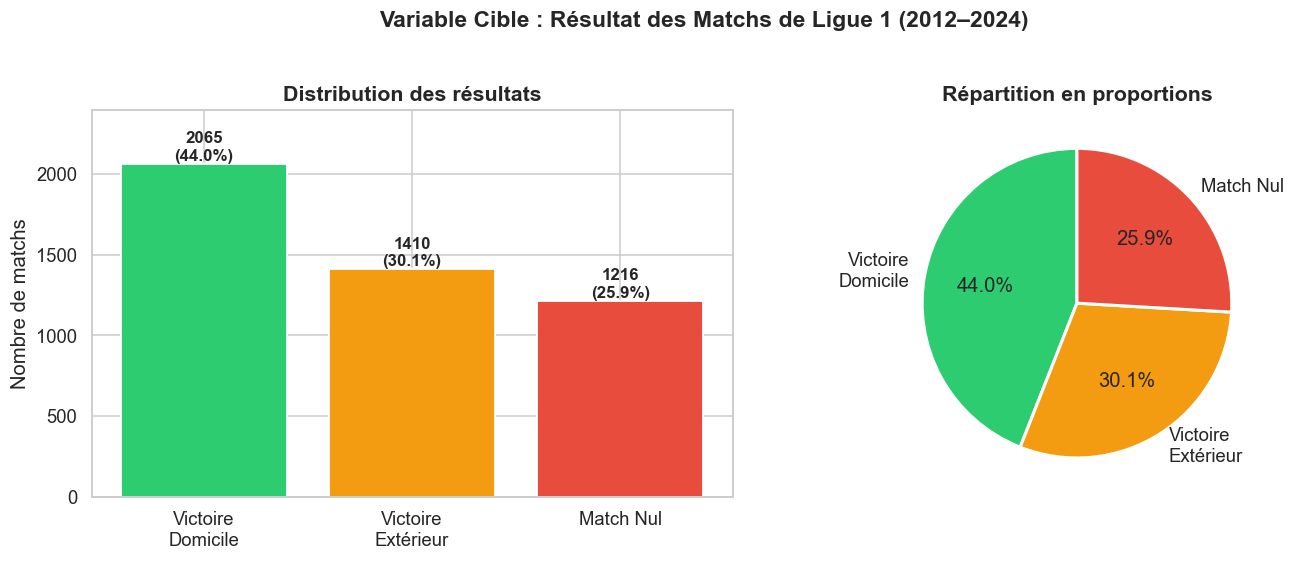

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_map = {1: 'Victoire\nDomicile', 0: 'Match Nul', -1: 'Victoire\nExtérieur'}
counts = matches['results'].map(label_map).value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Barplot
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for i, (lab, val) in enumerate(counts.items()):
    axes[0].text(i, val + 20, f'{val}\n({val/len(matches)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Distribution des résultats', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de matchs')
axes[0].set_ylim(0, 2400)

# Pie
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Répartition en proportions', fontsize=14, fontweight='bold')

plt.suptitle('Variable Cible : Résultat des Matchs de Ligue 1 (2012–2024)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**💡 Insight :** La variable cible est **déséquilibrée** : les victoires à domicile représentent ~44% des matchs, contre ~30% de victoires à l'extérieur et ~26% de nuls. Cet **avantage du terrain** est un phénomène bien documenté en football. Il faudra en tenir compte : un modèle "naïf" qui prédit toujours la victoire à domicile atteindrait ~44% d'accuracy — c'est notre **baseline** à dépasser.

### 3.2 Évolution des résultats par saison

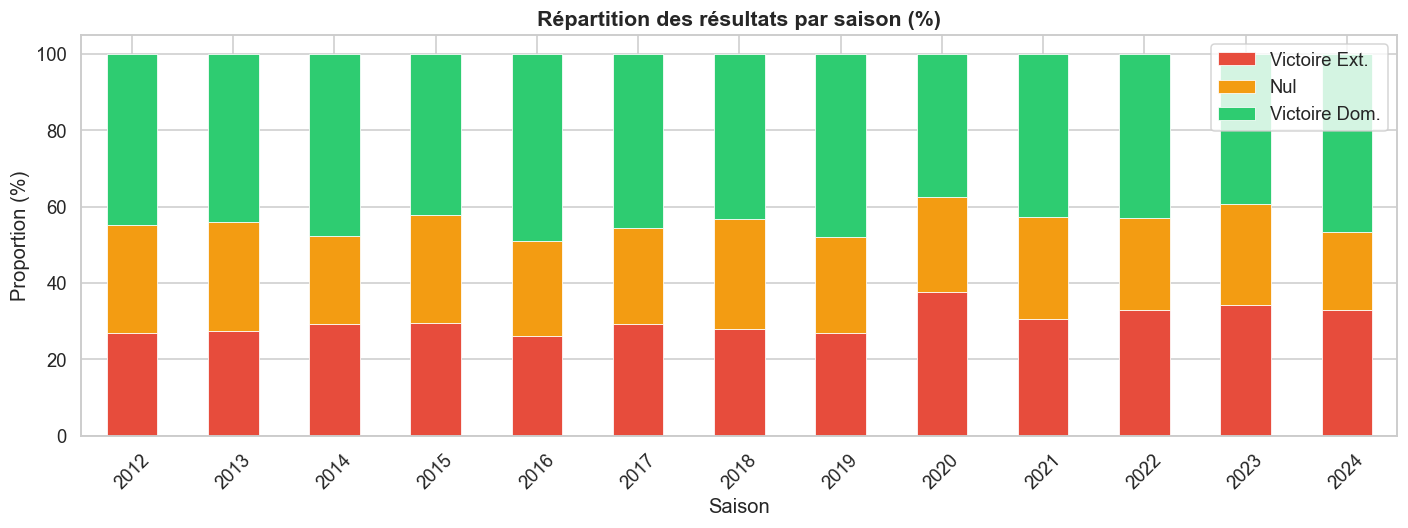

In [5]:
season_results = matches.groupby(['season', 'results']).size().unstack(fill_value=0)
season_results.columns = ['Victoire Ext.', 'Nul', 'Victoire Dom.']
season_pct = season_results.div(season_results.sum(axis=1), axis=0) * 100

ax = season_pct.plot(kind='bar', stacked=True, figsize=(13, 5),
                     color=['#e74c3c', '#f39c12', '#2ecc71'],
                     edgecolor='white', linewidth=0.5)
ax.set_title('Répartition des résultats par saison (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Saison')
ax.set_ylabel('Proportion (%)')
ax.legend(loc='upper right')
ax.set_xticklabels(season_pct.index, rotation=45)
plt.tight_layout()
plt.show()

**💡 Insight :** La répartition des résultats est **relativement stable** au fil des saisons. On observe toutefois une légère tendance à la hausse des victoires à l'extérieur sur les dernières saisons, ce qui pourrait refléter une évolution tactique du football moderne (pressing haut, jeu de possession des équipes visiteuses).

### 3.3 Analyse des buts

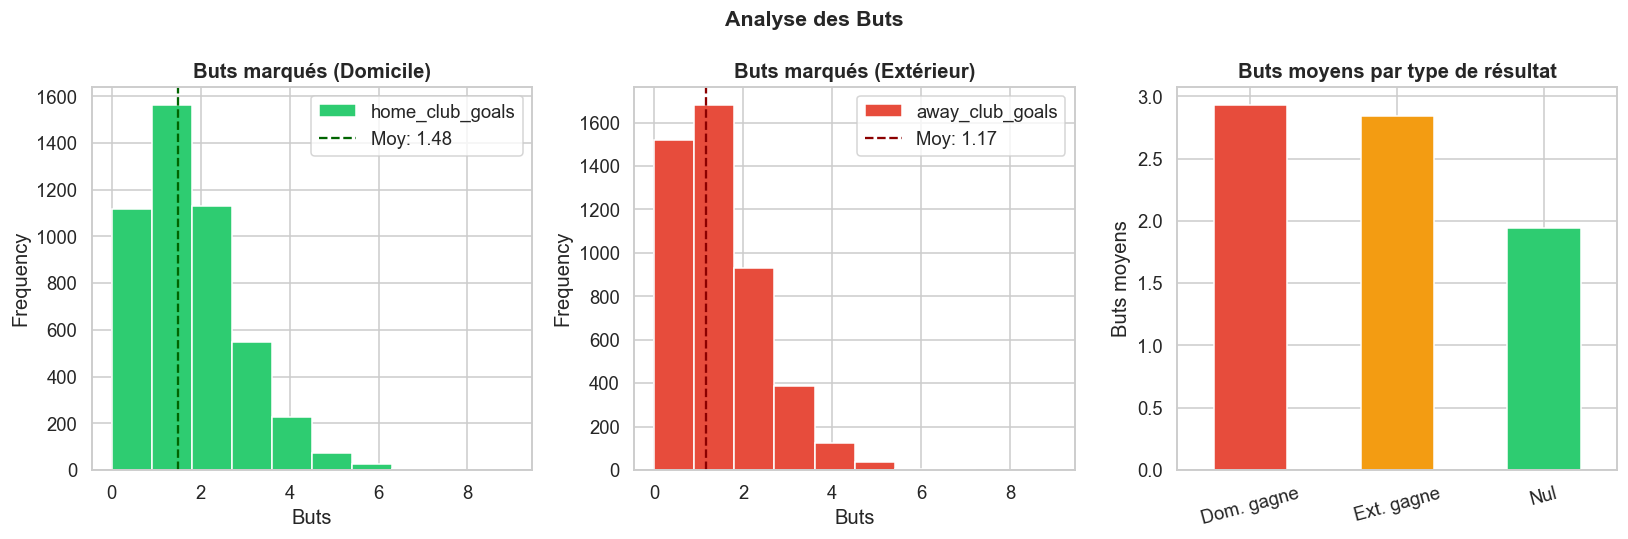

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution des buts domicile
matches['home_club_goals'].plot(kind='hist', bins=10, ax=axes[0],
                                 color='#2ecc71', edgecolor='white')
axes[0].set_title('Buts marqués (Domicile)', fontweight='bold')
axes[0].set_xlabel('Buts')
axes[0].axvline(matches['home_club_goals'].mean(), color='darkgreen',
                linestyle='--', label=f"Moy: {matches['home_club_goals'].mean():.2f}")
axes[0].legend()

# Distribution des buts extérieur
matches['away_club_goals'].plot(kind='hist', bins=10, ax=axes[1],
                                 color='#e74c3c', edgecolor='white')
axes[1].set_title('Buts marqués (Extérieur)', fontweight='bold')
axes[1].set_xlabel('Buts')
axes[1].axvline(matches['away_club_goals'].mean(), color='darkred',
                linestyle='--', label=f"Moy: {matches['away_club_goals'].mean():.2f}")
axes[1].legend()

# Buts totaux par résultat
matches['total_goals'] = matches['home_club_goals'] + matches['away_club_goals']
matches['result_label'] = matches['results'].map({1:'Dom. gagne', 0:'Nul', -1:'Ext. gagne'})
matches.groupby('result_label')['total_goals'].mean().plot(kind='bar', ax=axes[2],
    color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
axes[2].set_title('Buts moyens par type de résultat', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Buts moyens')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Analyse des Buts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Insight :** Les équipes à domicile marquent en moyenne **~1.48 buts** contre **~1.07** pour les équipes extérieures — confirmant l'avantage du terrain. Les matchs avec résultat décisif (victoire d'un camp) comptent plus de buts en moyenne que les nuls, ce qui est logique : les matchs nuls se terminent souvent 0-0 ou 1-1.

### 3.4 Analyse des positions au classement

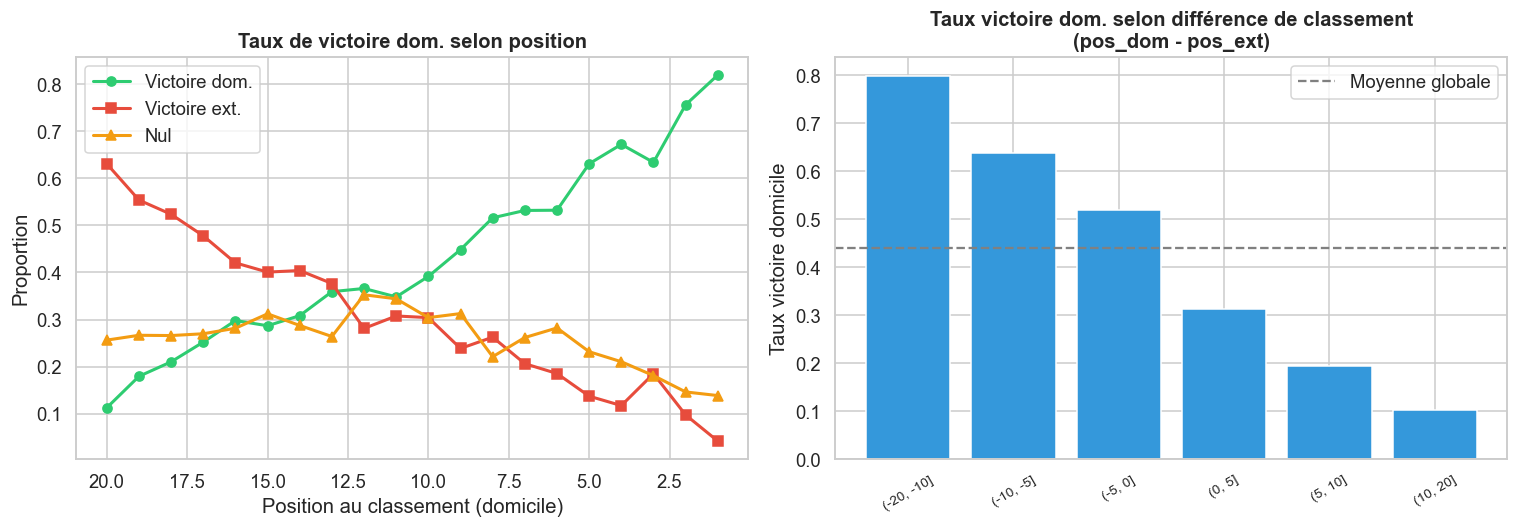

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Relation position domicile vs résultat
pos_result = matches.groupby(['home_club_position', 'results']).size().unstack(fill_value=0)
pos_result_pct = pos_result.div(pos_result.sum(axis=1), axis=0)
if 1 in pos_result_pct.columns:
    axes[0].plot(pos_result_pct.index, pos_result_pct[1], 'o-', color='#2ecc71',
                 label='Victoire dom.', linewidth=2)
if -1 in pos_result_pct.columns:
    axes[0].plot(pos_result_pct.index, pos_result_pct[-1], 's-', color='#e74c3c',
                 label='Victoire ext.', linewidth=2)
if 0 in pos_result_pct.columns:
    axes[0].plot(pos_result_pct.index, pos_result_pct[0], '^-', color='#f39c12',
                 label='Nul', linewidth=2)
axes[0].set_title('Taux de victoire dom. selon position', fontweight='bold')
axes[0].set_xlabel('Position au classement (domicile)')
axes[0].set_ylabel('Proportion')
axes[0].legend()
axes[0].invert_xaxis()

# Différence de position
matches['pos_diff'] = matches['home_club_position'] - matches['away_club_position']
pos_diff_bins = pd.cut(matches['pos_diff'], bins=[-20,-10,-5,0,5,10,20])
win_rate = matches.groupby(pos_diff_bins)['results'].apply(
    lambda x: (x == 1).mean()).reset_index()
win_rate.columns = ['pos_diff_bin', 'win_rate_home']
win_rate['pos_diff_bin'] = win_rate['pos_diff_bin'].astype(str)
axes[1].bar(range(len(win_rate)), win_rate['win_rate_home'],
            color='#3498db', edgecolor='white')
axes[1].set_xticks(range(len(win_rate)))
axes[1].set_xticklabels(win_rate['pos_diff_bin'], rotation=30, fontsize=9)
axes[1].set_title('Taux victoire dom. selon différence de classement\n(pos_dom - pos_ext)', fontweight='bold')
axes[1].set_ylabel('Taux victoire domicile')
axes[1].axhline(0.44, linestyle='--', color='gray', label='Moyenne globale')
axes[1].legend()

plt.tight_layout()
plt.show()

**💡 Insight :** La position au classement est **très discriminante** : les équipes mieux classées gagnent nettement plus souvent. La différence de position (domicile − extérieur) est une feature importante : quand l'équipe à domicile est bien mieux classée (valeur négative = meilleure position), son taux de victoire monte fortement.

### 3.5 Valeurs manquantes

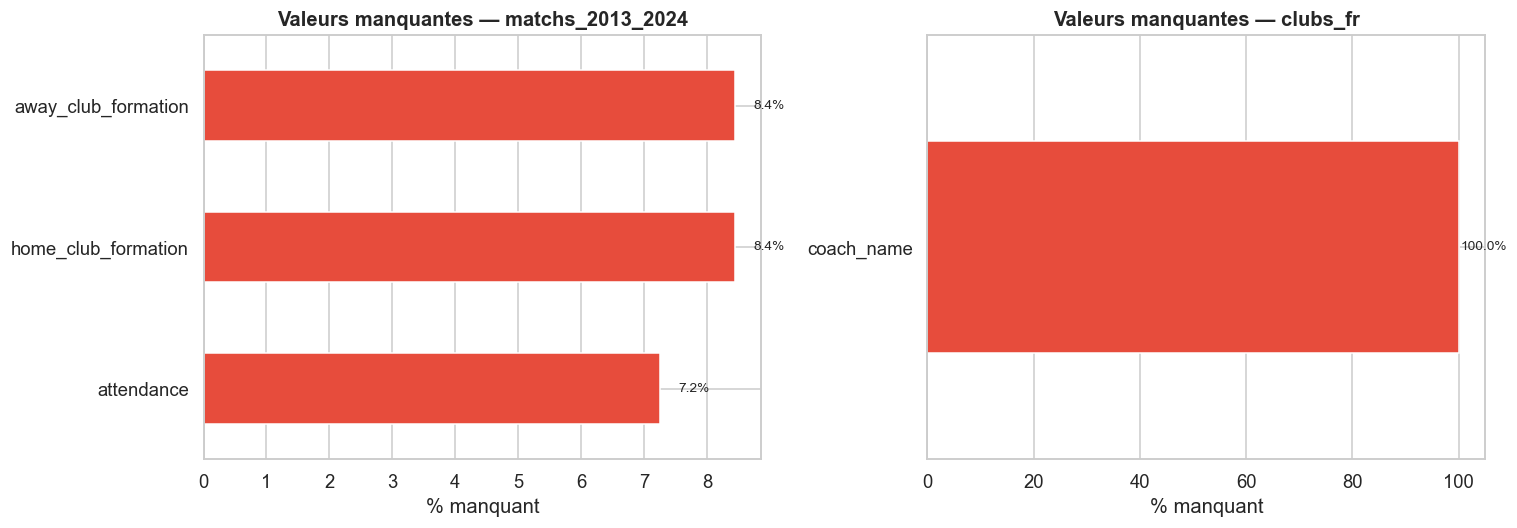


📊 Résumé valeurs manquantes (matchs) :


,nb_manquants
attendance,340
home_club_formation,396
away_club_formation,396


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('matchs_2013_2024', matches), ('clubs_fr', clubs)]):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0].sort_values(ascending=True)
    if len(null_pct) == 0:
        ax.text(0.5, 0.5, 'Aucune valeur manquante ✅',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
    else:
        null_pct.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
        for i, v in enumerate(null_pct.values):
            ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Valeurs manquantes — {name}', fontweight='bold')
    ax.set_xlabel('% manquant')

plt.tight_layout()
plt.show()

print('\n📊 Résumé valeurs manquantes (matchs) :')
display(matches.isnull().sum()[matches.isnull().sum() > 0].to_frame('nb_manquants'))

**💡 Insight :** Les valeurs manquantes sont limitées et concentrées sur des colonnes secondaires : `home_club_formation` / `away_club_formation` (~8%) et `attendance` (~7%). Ces colonnes seront gérées par imputation ou suppression selon leur importance pour le modèle.

### 3.6 Statistiques joueurs (appearances)

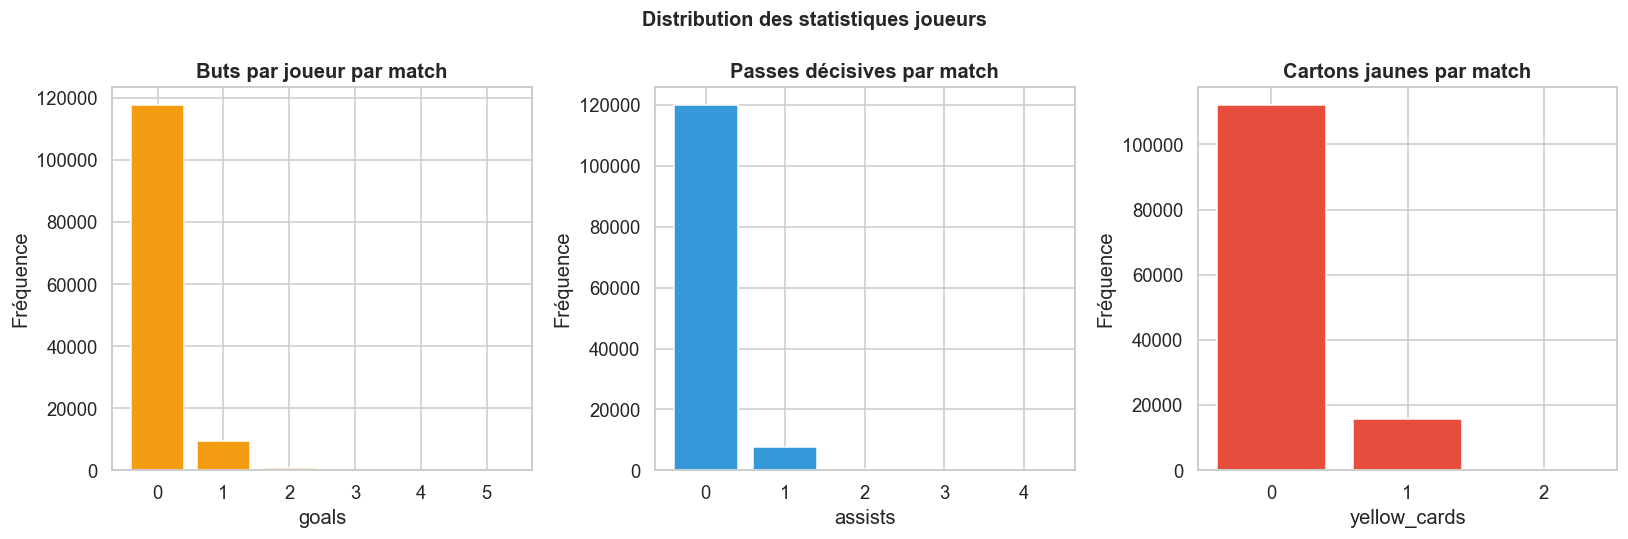

Statistiques descriptives appearances :


,goals,assists,yellow_cards,red_cards,minutes_played
count,128240.000,128240.000,128240.000,128240.000,128240.000
mean,0.090,0.068,0.128,0.006,68.961
std,0.318,0.268,0.343,0.076,30.015
min,0.000,0.000,0.000,0.000,1.000
25%,0.000,0.000,0.000,0.000,51.000
50%,0.000,0.000,0.000,0.000,90.000
75%,0.000,0.000,0.000,0.000,90.000
max,5.000,4.000,2.000,1.000,90.000


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color, title in zip(
    axes,
    ['goals', 'assists', 'yellow_cards'],
    ['#f39c12', '#3498db', '#e74c3c'],
    ['Buts par joueur par match', 'Passes décisives par match', 'Cartons jaunes par match']
):
    val = appearances[col].value_counts().head(6)
    ax.bar(val.index.astype(str), val.values, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')

plt.suptitle('Distribution des statistiques joueurs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Statistiques descriptives appearances :')
display(appearances[['goals','assists','yellow_cards','red_cards','minutes_played']].describe().round(3))

### 3.7 Valeur marchande des joueurs

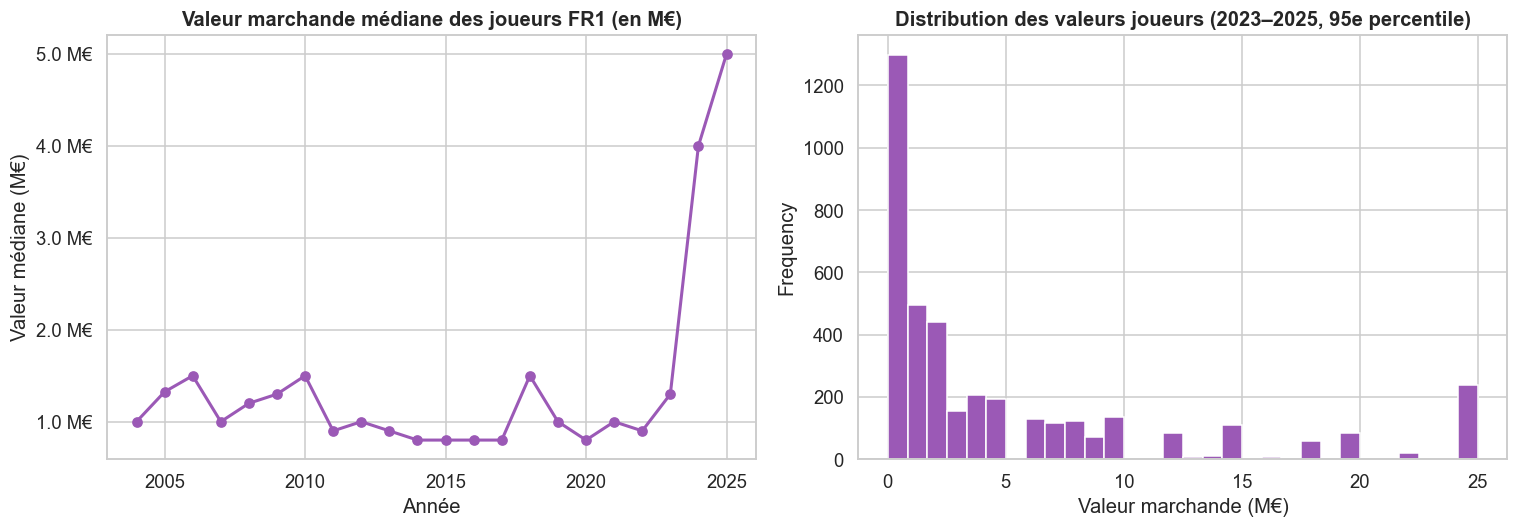

In [10]:
# Valeur par année
valuation['year'] = valuation['date'].dt.year
val_per_year = valuation.groupby('year')['market_value_in_eur'].median() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

val_per_year.plot(ax=axes[0], marker='o', color='#9b59b6', linewidth=2)
axes[0].set_title('Valeur marchande médiane des joueurs FR1 (en M€)', fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Valeur médiane (M€)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f M€'))

# Distribution des valeurs récentes (2023-2025)
recent_val = valuation[valuation['year'] >= 2023]['market_value_in_eur'] / 1e6
recent_val.clip(upper=recent_val.quantile(0.95)).plot(kind='hist', bins=30,
    ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Distribution des valeurs joueurs (2023–2025, 95e percentile)', fontweight='bold')
axes[1].set_xlabel('Valeur marchande (M€)')

plt.tight_layout()
plt.show()

**💡 Insight :** La valeur marchande a **fortement augmenté** depuis 2013, reflet de l'inflation dans le mercato du football européen. Agréger la **valeur totale de l'effectif** par club et par saison sera une feature pertinente pour mesurer le niveau relatif des équipes.

### 3.8 Matrice de corrélation

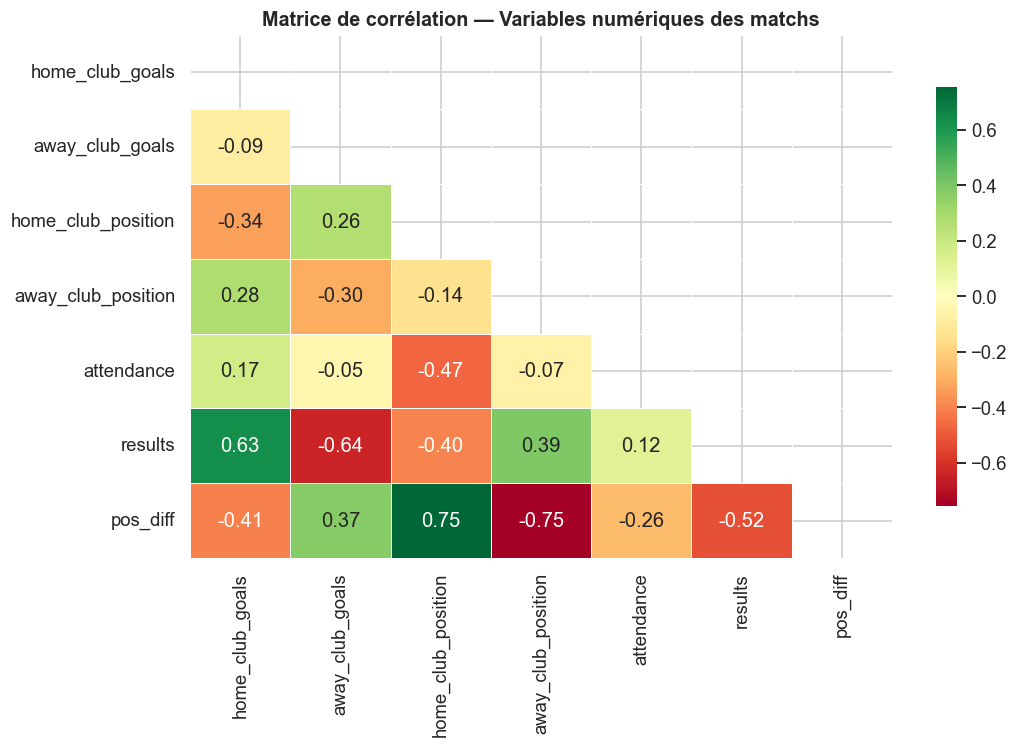

In [11]:
num_cols = ['home_club_goals', 'away_club_goals', 'home_club_position',
            'away_club_position', 'attendance', 'results', 'pos_diff']

corr = matches[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation — Variables numériques des matchs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Insight :** Corrélations notables avec `results` :
- `home_club_goals` (+) et `away_club_goals` (−) : attendu, les buts déterminent le résultat
- `home_club_position` (−) : une meilleure position (valeur basse) favorise la victoire à domicile
- `pos_diff` : la différence de position a un pouvoir prédictif modéré

> ⚠️ Attention : `home_club_goals` et `away_club_goals` sont des **données de fuite** (elles contiennent le résultat). Elles ne seront **pas utilisées** dans le modèle de prédiction.

---
## 4. Prétraitement des Données

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.1 Nettoyage de la valeur marchande
# On garde la dernière valeur connue avant chaque saison pour chaque joueur
# ─────────────────────────────────────────────────────────────────────────────
valuation_clean = valuation.sort_values('date').drop_duplicates(
    subset=['player_id', 'current_club_id'], keep='last'
)

# Valeur totale de l'effectif par club
club_squad_value = valuation_clean.groupby('current_club_id')['market_value_in_eur'].agg(
    total_squad_value='sum',
    avg_player_value='mean',
    squad_size_val='count'
).reset_index().rename(columns={'current_club_id': 'club_id'})

print(f'Clubs avec valeur marchande : {len(club_squad_value)}')
display(club_squad_value.sort_values('total_squad_value', ascending=False).head(5))

Clubs avec valeur marchande : 36


,club_id,total_squad_value,avg_player_value,squad_size_val
8,583,2041550000,1.701292e+07,120
1,162,1166045000,8.969577e+06,130
18,1041,1031375000,7.419964e+06,139
2,244,1004475000,7.123936e+06,141
19,1082,914875000,6.983779e+06,131


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.2 Nettoyage des clubs_fr
# ─────────────────────────────────────────────────────────────────────────────
def parse_transfer(val):
    """Convertit les strings de transferts type '+€62.11m' en float."""
    if pd.isna(val):
        return 0.0
    val = str(val).replace('€', '').replace('+', '').strip()
    if val.endswith('m'):
        return float(val[:-1]) * 1e6
    elif val.endswith('k'):
        return float(val[:-1]) * 1e3
    try:
        return float(val)
    except:
        return 0.0

clubs_clean = clubs.copy()
clubs_clean['net_transfer_eur'] = clubs_clean['net_transfer_record'].apply(parse_transfer)
clubs_clean = clubs_clean.merge(club_squad_value, on='club_id', how='left')

print('clubs_fr après nettoyage :')
display(clubs_clean[['club_id','name','squad_size','average_age',
                      'net_transfer_eur','total_squad_value']].head(8))

clubs_fr après nettoyage :


,club_id,name,squad_size,average_age,net_transfer_eur,total_squad_value
0,10004,Paris Football Club,31,28.5,-72300000.0,17850000
1,1041,Olympique Lyonnais,28,25.5,62110000.0,1031375000
2,1082,Lille Olympique Sporting Club,27,26.5,61600000.0,914875000
3,1095,ESTAC Troyes,29,23.1,-0.0,147410000
4,1147,AC Ajaccio,24,27.5,-0.0,50650000
5,1158,Football Club Lorient-Bretagne Sud,25,25.9,600000.0,296900000
6,1159,AS Nancy-Lorraine,27,25.7,-0.0,30875000
7,1160,Nîmes Olympique,26,25.4,2500000.0,88750000


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.3 Statistiques joueurs agrégées par club et par match
# ─────────────────────────────────────────────────────────────────────────────
app_per_match = appearances.groupby(['game_id', 'player_club_id']).agg(
    team_goals_app   = ('goals', 'sum'),
    team_assists     = ('assists', 'sum'),
    team_yellow      = ('yellow_cards', 'sum'),
    team_red         = ('red_cards', 'sum'),
    team_mins        = ('minutes_played', 'mean'),
    nb_players       = ('player_id', 'count')
).reset_index()

print(f'Agrégats par match/club : {app_per_match.shape}')
display(app_per_match.head(4))

Agrégats par match/club : (9351, 8)


,game_id,player_club_id,team_goals_app,team_assists,team_yellow,team_red,team_mins,nb_players
0,2223841,1423,1,1,1,1,69.642857,14
1,2223841,3911,2,0,2,0,70.714286,14
2,2223842,1147,1,0,1,0,76.153846,13
3,2223842,3911,0,0,2,0,70.714286,14


---
## 5. Feature Engineering

C'est la **partie la plus critique** du projet. Un bon feature engineering peut faire la différence entre un modèle médiocre et un modèle performant. Nous allons construire des features qui capturent :

1. La **forme récente** des équipes
2. Les **performances à domicile vs extérieur**
3. L'**historique des confrontations directes**
4. Le **niveau de l'effectif** (valeur marchande)
5. La **fatigue** et régularité (rotation)
6. Des **features de momentum** avancées

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 1 : Forme récente (5 derniers matchs)
#
# Pourquoi ? La forme d'une équipe sur les derniers matchs capture son
# niveau de confiance, sa dynamique de jeu et d'éventuelles blessures.
# Un modèle basé sur la saison entière ignore les tendances récentes.
# ─────────────────────────────────────────────────────────────────────────────

def compute_recent_form(matches_df, n_games=5):
    """Calcule les stats des n derniers matchs pour chaque équipe, pour chaque match."""
    df = matches_df.sort_values('date').copy().reset_index(drop=True)
    
    rows = []
    for idx, row in df.iterrows():
        gid  = row['game_id']
        hid  = row['home_club_id']
        aid  = row['away_club_id']
        date = row['date']
        
        def get_last_n(club_id):
            mask = (df['date'] < date) & (
                (df['home_club_id'] == club_id) | (df['away_club_id'] == club_id)
            )
            return df[mask].tail(n_games)
        
        def stats(prev, cid):
            if len(prev) == 0:
                return dict(pts=0, gf=0, ga=0, wins=0, draws=0, n=0)
            pts = wins = draws = gf = ga = 0
            for _, m in prev.iterrows():
                is_home = (m['home_club_id'] == cid)
                res = m['results']
                gf += m['home_club_goals'] if is_home else m['away_club_goals']
                ga += m['away_club_goals'] if is_home else m['home_club_goals']
                if (is_home and res == 1) or (not is_home and res == -1):
                    pts += 3; wins += 1
                elif res == 0:
                    pts += 1; draws += 1
            n = len(prev)
            return dict(pts=pts/n, gf=gf/n, ga=ga/n, wins=wins/n, draws=draws/n, n=n)
        
        sh = stats(get_last_n(hid), hid)
        sa = stats(get_last_n(aid), aid)
        
        rows.append({
            'game_id'          : gid,
            'home_form_pts'    : sh['pts'],
            'home_form_gf'     : sh['gf'],
            'home_form_ga'     : sh['ga'],
            'home_form_wins'   : sh['wins'],
            'home_form_draws'  : sh['draws'],
            'home_form_n'      : sh['n'],
            'away_form_pts'    : sa['pts'],
            'away_form_gf'     : sa['gf'],
            'away_form_ga'     : sa['ga'],
            'away_form_wins'   : sa['wins'],
            'away_form_draws'  : sa['draws'],
            'away_form_n'      : sa['n'],
            # Différentiels
            'form_pts_diff'    : sh['pts'] - sa['pts'],
            'form_gf_diff'     : sh['gf']  - sa['gf'],
            'form_ga_diff'     : sh['ga']  - sa['ga'],
        })
    
    return pd.DataFrame(rows)

print('⏳ Calcul de la forme récente (peut prendre ~1-2 min)...')
form_df = compute_recent_form(matches)
print(f'✅ Forme calculée : {form_df.shape}')
display(form_df.head(3))

⏳ Calcul de la forme récente (peut prendre ~1-2 min)...
✅ Forme calculée : (4691, 16)


,game_id,home_form_pts,home_form_gf,home_form_ga,home_form_wins,home_form_draws,home_form_n,away_form_pts,away_form_gf,away_form_ga,away_form_wins,away_form_draws,away_form_n,form_pts_diff,form_gf_diff,form_ga_diff
0,2229837,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
1,2229843,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
2,2229840,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 2 : Performance à domicile / extérieur sur la saison en cours
#
# Pourquoi ? Certaines équipes sont très fortes à domicile mais fragiles
# à l'extérieur (et vice-versa). Capturer cette asymétrie est crucial.
# ─────────────────────────────────────────────────────────────────────────────

def home_away_stats(matches_df):
    """Stats domicile/extérieur cumulées jusqu'à la date du match (même saison)."""
    df = matches_df.sort_values(['season', 'date']).copy()
    rows = []
    
    for idx, row in df.iterrows():
        season = row['season']
        date   = row['date']
        hid    = row['home_club_id']
        aid    = row['away_club_id']
        
        # Matchs à dom de l'équipe dom, cette saison, avant cette date
        prev_hh = df[(df['season'] == season) & (df['date'] < date) &
                     (df['home_club_id'] == hid)]
        prev_aa = df[(df['season'] == season) & (df['date'] < date) &
                     (df['away_club_id'] == aid)]
        
        def win_rate(sub, is_home_team, win_val):
            if len(sub) == 0: return 0.0
            return (sub['results'] == win_val).mean()
        
        rows.append({
            'game_id'             : row['game_id'],
            'home_home_winrate'   : win_rate(prev_hh, True, 1),
            'home_home_n'         : len(prev_hh),
            'home_home_gf_avg'    : prev_hh['home_club_goals'].mean() if len(prev_hh) else 0,
            'home_home_ga_avg'    : prev_hh['away_club_goals'].mean() if len(prev_hh) else 0,
            'away_away_winrate'   : win_rate(prev_aa, False, -1),
            'away_away_n'         : len(prev_aa),
            'away_away_gf_avg'    : prev_aa['away_club_goals'].mean() if len(prev_aa) else 0,
            'away_away_ga_avg'    : prev_aa['home_club_goals'].mean() if len(prev_aa) else 0,
        })
    
    return pd.DataFrame(rows)

print('⏳ Calcul des stats dom/ext...')
home_away_df = home_away_stats(matches)
print(f'✅ Stats dom/ext calculées : {home_away_df.shape}')
display(home_away_df.head(3))

⏳ Calcul des stats dom/ext...
✅ Stats dom/ext calculées : (4691, 9)


,game_id,home_home_winrate,home_home_n,home_home_gf_avg,home_home_ga_avg,away_away_winrate,away_away_n,away_away_gf_avg,away_away_ga_avg
0,2229837,0.0,0,0.0,0.0,0.0,0,0.0,0.0
1,2229834,0.0,0,0.0,0.0,0.0,0,0.0,0.0
2,2229835,0.0,0,0.0,0.0,0.0,0,0.0,0.0


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 3 : Historique des confrontations directes (H2H)
#
# Pourquoi ? Certaines équipes ont des "matchs de bête noire" —
# des adversaires contre lesquels elles performent toujours moins bien.
# L'historique direct capture cette dynamique psychologique/tactique.
# ─────────────────────────────────────────────────────────────────────────────

def h2h_stats(matches_df, n=10):
    """Stats des n dernières confrontations entre les deux équipes."""
    df = matches_df.sort_values('date').copy()
    rows = []
    
    for _, row in df.iterrows():
        hid  = row['home_club_id']
        aid  = row['away_club_id']
        date = row['date']
        
        prev = df[
            (df['date'] < date) & (
                ((df['home_club_id'] == hid) & (df['away_club_id'] == aid)) |
                ((df['home_club_id'] == aid) & (df['away_club_id'] == hid))
            )
        ].tail(n)
        
        if len(prev) == 0:
            rows.append({'game_id': row['game_id'],
                         'h2h_home_wins': 0, 'h2h_away_wins': 0,
                         'h2h_draws': 0, 'h2h_n': 0,
                         'h2h_home_gf_avg': 0, 'h2h_away_gf_avg': 0})
            continue
        
        home_wins = away_wins = draws = hgf = agf = 0
        for _, m in prev.iterrows():
            if m['home_club_id'] == hid:
                hgf += m['home_club_goals']; agf += m['away_club_goals']
                if m['results'] == 1:  home_wins += 1
                elif m['results'] == -1: away_wins += 1
                else: draws += 1
            else:  # hid was away
                hgf += m['away_club_goals']; agf += m['home_club_goals']
                if m['results'] == -1: home_wins += 1
                elif m['results'] == 1: away_wins += 1
                else: draws += 1
        
        n_prev = len(prev)
        rows.append({
            'game_id'          : row['game_id'],
            'h2h_home_wins'    : home_wins / n_prev,
            'h2h_away_wins'    : away_wins / n_prev,
            'h2h_draws'        : draws / n_prev,
            'h2h_n'            : n_prev,
            'h2h_home_gf_avg'  : hgf / n_prev,
            'h2h_away_gf_avg'  : agf / n_prev,
        })
    
    return pd.DataFrame(rows)

print('⏳ Calcul des confrontations directes (H2H)...')
h2h_df = h2h_stats(matches)
print(f'✅ H2H calculé : {h2h_df.shape}')
display(h2h_df.head(3))

⏳ Calcul des confrontations directes (H2H)...
✅ H2H calculé : (4691, 7)


,game_id,h2h_home_wins,h2h_away_wins,h2h_draws,h2h_n,h2h_home_gf_avg,h2h_away_gf_avg
0,2229837,0.0,0.0,0.0,0,0.0,0.0
1,2229843,0.0,0.0,0.0,0,0.0,0.0
2,2229840,0.0,0.0,0.0,0,0.0,0.0


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 4 : Classement et différentiel
#
# Pourquoi ? La position au classement est un excellent proxy du niveau
# de l'équipe à un instant T. La différence capture l'écart de niveau.
# ─────────────────────────────────────────────────────────────────────────────

matches['pos_diff']          = matches['home_club_position'] - matches['away_club_position']
matches['pos_ratio']         = matches['home_club_position'] / (matches['away_club_position'] + 1)
matches['home_is_top_half']  = (matches['home_club_position'] <= 10).astype(int)
matches['away_is_top_half']  = (matches['away_club_position'] <= 10).astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 5 : Statistiques agrégées de saison (buts marqués / encaissés)
#
# Pourquoi ? La moyenne de buts sur toute la saison donne une image
# plus stable du niveau offensif et défensif d'une équipe.
# ─────────────────────────────────────────────────────────────────────────────

def season_cumulative_stats(df):
    """Pour chaque match, calcule les stats cumulées de la saison jusqu'à cette journée."""
    df = df.sort_values(['season', 'date']).copy()
    rows = []
    
    for _, row in df.iterrows():
        s = row['season']; d = row['date']
        hid = row['home_club_id']; aid = row['away_club_id']
        
        def cum_stats(cid):
            prev_h = df[(df['season']==s) & (df['date']<d) & (df['home_club_id']==cid)]
            prev_a = df[(df['season']==s) & (df['date']<d) & (df['away_club_id']==cid)]
            gf = prev_h['home_club_goals'].sum() + prev_a['away_club_goals'].sum()
            ga = prev_h['away_club_goals'].sum() + prev_a['home_club_goals'].sum()
            n  = len(prev_h) + len(prev_a)
            return (gf/n if n else 0, ga/n if n else 0, n)
        
        hgf, hga, hn = cum_stats(hid)
        agf, aga, an = cum_stats(aid)
        
        rows.append({'game_id': row['game_id'],
                     'home_season_gf': hgf, 'home_season_ga': hga, 'home_season_n': hn,
                     'away_season_gf': agf, 'away_season_ga': aga, 'away_season_n': an,
                     'season_gf_diff': hgf - agf, 'season_ga_diff': hga - aga})
    
    return pd.DataFrame(rows)

print('⏳ Calcul des stats cumulées de saison...')
season_stats_df = season_cumulative_stats(matches)
print(f'✅ Stats saison calculées : {season_stats_df.shape}')

⏳ Calcul des stats cumulées de saison...
✅ Stats saison calculées : (4691, 9)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 6 : Valeur marchande des effectifs
#
# Pourquoi ? La valeur de l'effectif est un proxy de la qualité globale
# de l'équipe. Les clubs avec des effectifs plus chers gagnent
# statistiquement plus souvent — c'est un indicateur long terme.
# ─────────────────────────────────────────────────────────────────────────────

# Stats valuations agrégées par (club, saison)
valuation['season'] = valuation['date'].dt.year - 1  # saison démarre en été
club_val_season = valuation.groupby(['current_club_id', 'season'])['market_value_in_eur'].agg(
    squad_total_value='sum',
    squad_avg_value='mean'
).reset_index()
club_val_season.rename(columns={'current_club_id': 'club_id'}, inplace=True)

# Merge pour chaque match
def add_valuation_features(matches_df, val_df):
    df = matches_df.copy()
    df = df.merge(val_df.rename(columns={
        'club_id': 'home_club_id',
        'squad_total_value': 'home_squad_value',
        'squad_avg_value': 'home_avg_player_value'
    }), on=['home_club_id', 'season'], how='left')
    df = df.merge(val_df.rename(columns={
        'club_id': 'away_club_id',
        'squad_total_value': 'away_squad_value',
        'squad_avg_value': 'away_avg_player_value'
    }), on=['away_club_id', 'season'], how='left')
    df['squad_value_ratio'] = df['home_squad_value'] / (df['away_squad_value'] + 1)
    df['squad_value_diff']  = df['home_squad_value'] - df['away_squad_value']
    return df

matches = add_valuation_features(matches, club_val_season)
print('✅ Features valeur marchande ajoutées')
display(matches[['home_club_name','away_club_name','home_squad_value','away_squad_value','squad_value_ratio']].head(4))

✅ Features valeur marchande ajoutées


,home_club_name,away_club_name,home_squad_value,away_squad_value,squad_value_ratio
0,Stade brestois 29,Valenciennes FC,85900000,46550000,1.845328
1,AC Ajaccio,Stade brestois 29,78500000,85900000,0.913853
2,Stade Reims,AS Nancy-Lorraine,83600000,40050000,2.087391
3,Montpellier HSC,AS Saint-Étienne,174875000,261550000,0.668610


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 7 : Stats joueurs agrégées par équipe
#
# Pourquoi ? Les performances individuelles (buts, passes, cartons) reflètent
# la dynamique collective d'une équipe sur la saison en cours.
# ─────────────────────────────────────────────────────────────────────────────

# Statistiques cumulées par joueur (toute la saison)
appearances['season'] = appearances['date'].dt.year.apply(
    lambda y: y - 1 if appearances['date'].dt.month.loc[appearances['date'].dt.year == y].mean() < 7 else y
)
# Version simplifiée : stats par club/game via app_per_match déjà calculé
# On merge les stats de l'équipe dom et ext

app_home = app_per_match.rename(columns={
    'player_club_id': 'home_club_id',
    'team_goals_app': 'home_app_goals', 'team_assists': 'home_app_assists',
    'team_yellow': 'home_yellow', 'team_red': 'home_red',
    'team_mins': 'home_mins', 'nb_players': 'home_nb_players'
})
app_away = app_per_match.rename(columns={
    'player_club_id': 'away_club_id',
    'team_goals_app': 'away_app_goals', 'team_assists': 'away_app_assists',
    'team_yellow': 'away_yellow', 'team_red': 'away_red',
    'team_mins': 'away_mins', 'nb_players': 'away_nb_players'
})

matches = matches.merge(app_home[['game_id','home_club_id','home_app_goals',
                                   'home_app_assists','home_yellow','home_red']],
                        on=['game_id','home_club_id'], how='left')
matches = matches.merge(app_away[['game_id','away_club_id','away_app_goals',
                                   'away_app_assists','away_yellow','away_red']],
                        on=['game_id','away_club_id'], how='left')

print('✅ Features joueurs ajoutées')
print(f'Shape matches : {matches.shape}')

✅ Features joueurs ajoutées
Shape matches : (4691, 43)


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 8 : Features clubs (effectif, âge, transferts)
#
# Pourquoi ? Un effectif jeune peut manquer d'expérience. Un bilan
# transfert positif indique des investissements récents. La taille
# du stade reflète le soutien du public.
# ─────────────────────────────────────────────────────────────────────────────

club_feats = clubs_clean[['club_id','squad_size','average_age',
                           'foreigners_percentage','national_team_players',
                           'stadium_seats','net_transfer_eur']]

matches = matches.merge(
    club_feats.rename(columns={c: f'home_{c}' for c in club_feats.columns if c != 'club_id'}
                     ).rename(columns={'club_id': 'home_club_id'}),
    on='home_club_id', how='left'
)
matches = matches.merge(
    club_feats.rename(columns={c: f'away_{c}' for c in club_feats.columns if c != 'club_id'}
                     ).rename(columns={'club_id': 'away_club_id'}),
    on='away_club_id', how='left'
)

print('✅ Features clubs ajoutées')
print(f'Shape matches : {matches.shape}')

✅ Features clubs ajoutées
Shape matches : (4691, 55)


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# ASSEMBLAGE FINAL DU DATASET
# ─────────────────────────────────────────────────────────────────────────────

dataset = matches.merge(form_df, on='game_id', how='left')
dataset = dataset.merge(home_away_df, on='game_id', how='left')
dataset = dataset.merge(h2h_df, on='game_id', how='left')
dataset = dataset.merge(season_stats_df, on='game_id', how='left')

print(f'✅ Dataset final assemblé : {dataset.shape}')
print(f'Colonnes : {list(dataset.columns)}')

✅ Dataset final assemblé : (4691, 92)
Colonnes : ['Unnamed: 0', 'game_id', 'season', 'round', 'date', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'home_club_position', 'away_club_position', 'home_club_manager_name', 'away_club_manager_name', 'stadium', 'attendance', 'referee', 'home_club_formation', 'away_club_formation', 'home_club_name', 'away_club_name', 'aggregate', 'competition_type', 'results', 'total_goals', 'result_label', 'pos_diff', 'pos_ratio', 'home_is_top_half', 'away_is_top_half', 'home_squad_value', 'home_avg_player_value', 'away_squad_value', 'away_avg_player_value', 'squad_value_ratio', 'squad_value_diff', 'home_app_goals', 'home_app_assists', 'home_yellow', 'home_red', 'away_app_goals', 'away_app_assists', 'away_yellow', 'away_red', 'home_squad_size', 'home_average_age', 'home_foreigners_percentage', 'home_national_team_players', 'home_stadium_seats', 'home_net_transfer_eur', 'away_squad_size', 'away_average_age', 'away_foreigners_percentage'

### 5.1 Visualisation de l'impact des features engineerées

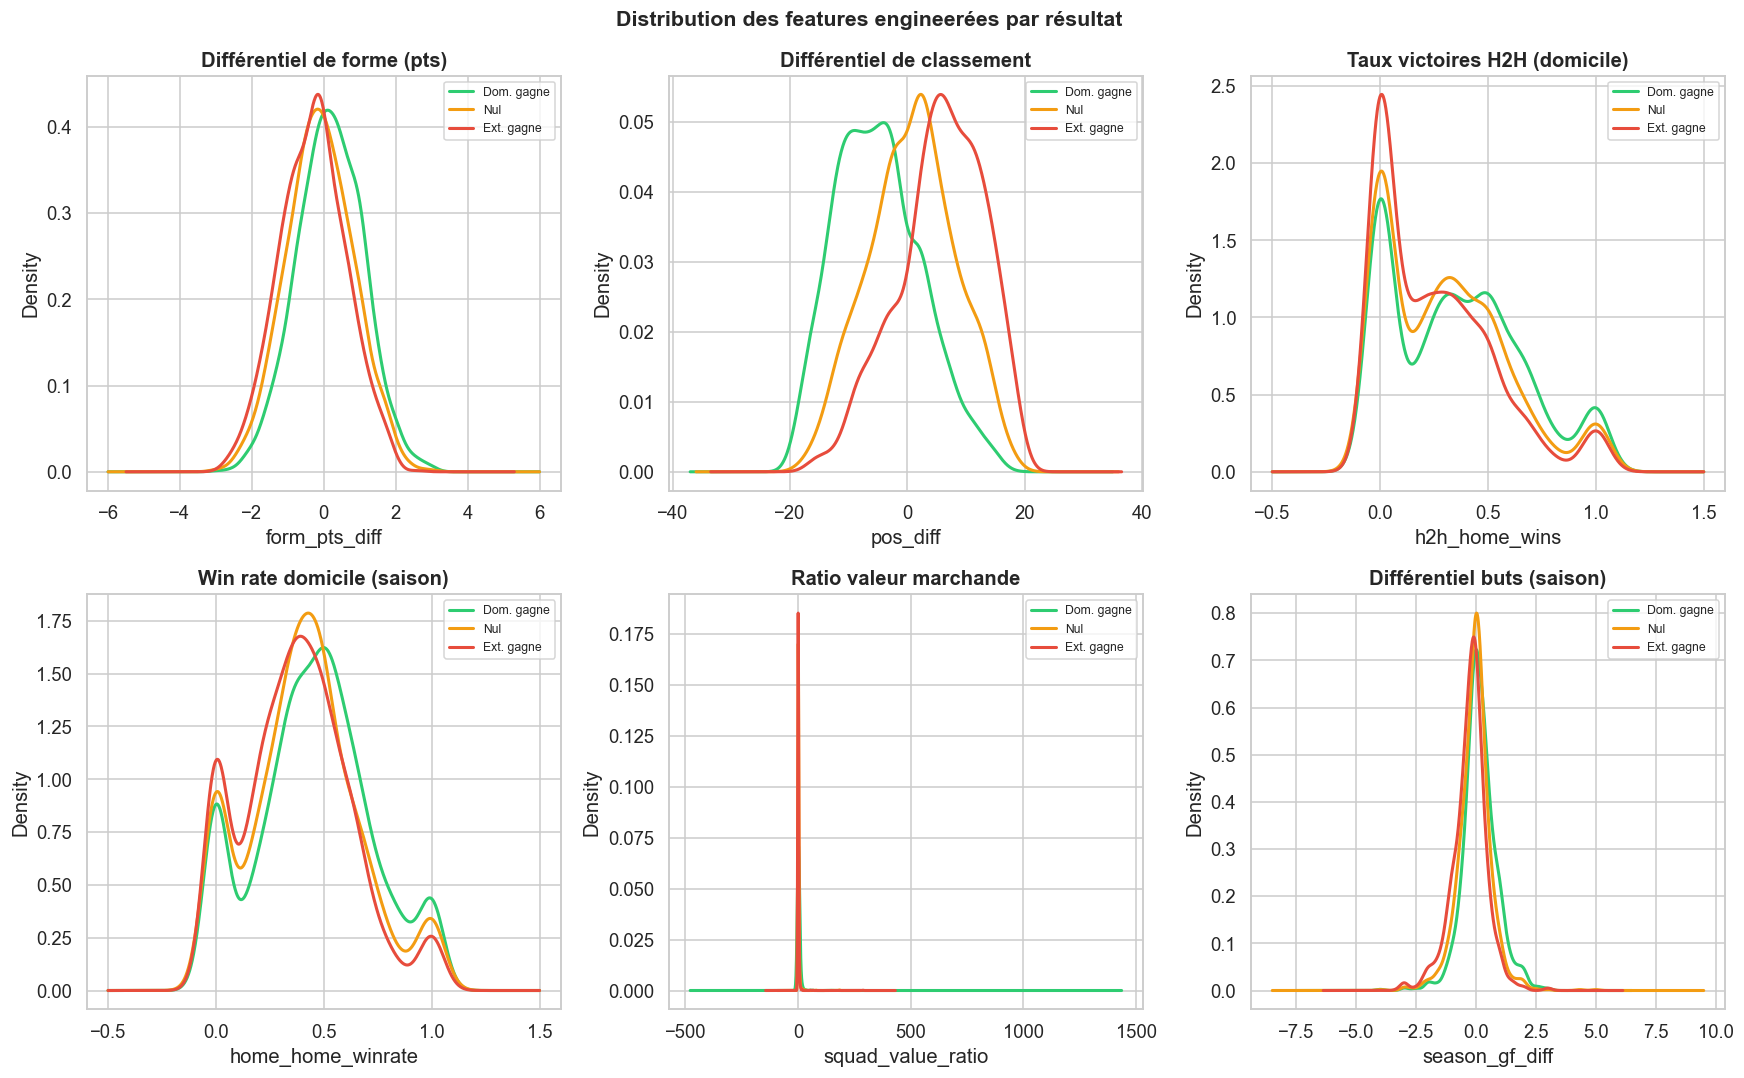

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
features_to_plot = [
    ('form_pts_diff',       'Différentiel de forme (pts)'),
    ('pos_diff',            'Différentiel de classement'),
    ('h2h_home_wins',       'Taux victoires H2H (domicile)'),
    ('home_home_winrate',   'Win rate domicile (saison)'),
    ('squad_value_ratio',   'Ratio valeur marchande'),
    ('season_gf_diff',      'Différentiel buts (saison)'),
]
colors_res = {1: '#2ecc71', 0: '#f39c12', -1: '#e74c3c'}
labels_res = {1: 'Dom. gagne', 0: 'Nul', -1: 'Ext. gagne'}

for ax, (feat, title) in zip(axes, features_to_plot):
    if feat not in dataset.columns:
        ax.set_visible(False)
        continue
    for res in [1, 0, -1]:
        sub = dataset[dataset['results'] == res][feat].dropna()
        sub.plot(kind='kde', ax=ax, label=labels_res[res],
                 color=colors_res[res], linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

plt.suptitle('Distribution des features engineerées par résultat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Insight :** Les distributions des features engineerées sont **bien séparées** selon le résultat pour plusieurs variables clés :
- `form_pts_diff` et `pos_diff` montrent un glissement clair entre les 3 classes
- `home_home_winrate` discrimine bien les victoires à domicile
- `squad_value_ratio` montre que les équipes plus riches gagnent plus souvent

Ces features ont un **pouvoir discriminant** avéré et seront utiles au modèle.

---
## 6. Préparation des Données pour le ML

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Sélection des features (sans data leakage !)
# On exclut : buts, résultats futurs, colonnes d'identité
# ─────────────────────────────────────────────────────────────────────────────

EXCLUDE = [
    'game_id', 'season', 'round', 'date', 'results',
    'home_club_goals', 'away_club_goals',   # ← data leakage !
    'home_club_name', 'away_club_name',
    'home_club_manager_name', 'away_club_manager_name',
    'stadium', 'referee', 'aggregate', 'competition_type',
    'home_club_formation', 'away_club_formation',
    'result_label', 'total_goals',
    'Unnamed: 0',
    # Stats app = peuvent créer data leakage si mal gérées
    'home_app_goals', 'away_app_goals',
    'home_app_assists', 'away_app_assists',
]

FEATURE_COLS = [c for c in dataset.columns if c not in EXCLUDE]
print(f'Nombre de features : {len(FEATURE_COLS)}')
print('Features sélectionnées :')
for c in FEATURE_COLS:
    print(f'  - {c}')

Nombre de features : 68
Features sélectionnées :
  - home_club_id
  - away_club_id
  - home_club_position
  - away_club_position
  - attendance
  - pos_diff
  - pos_ratio
  - home_is_top_half
  - away_is_top_half
  - home_squad_value
  - home_avg_player_value
  - away_squad_value
  - away_avg_player_value
  - squad_value_ratio
  - squad_value_diff
  - home_yellow
  - home_red
  - away_yellow
  - away_red
  - home_squad_size
  - home_average_age
  - home_foreigners_percentage
  - home_national_team_players
  - home_stadium_seats
  - home_net_transfer_eur
  - away_squad_size
  - away_average_age
  - away_foreigners_percentage
  - away_national_team_players
  - away_stadium_seats
  - away_net_transfer_eur
  - home_form_pts
  - home_form_gf
  - home_form_ga
  - home_form_wins
  - home_form_draws
  - home_form_n
  - away_form_pts
  - away_form_gf
  - away_form_ga
  - away_form_wins
  - away_form_draws
  - away_form_n
  - form_pts_diff
  - form_gf_diff
  - form_ga_diff
  - home_home_winrate


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Encodage des club_id (label encoding)
# ─────────────────────────────────────────────────────────────────────────────

le = LabelEncoder()
if 'home_club_id' in FEATURE_COLS:
    all_clubs = pd.concat([
        dataset['home_club_id'], dataset['away_club_id'],
        m2025['home_club_id'],   m2025['away_club_id']
    ]).unique()
    le.fit(all_clubs)
    dataset['home_club_id'] = le.transform(dataset['home_club_id'])
    dataset['away_club_id'] = le.transform(dataset['away_club_id'])

# ─────────────────────────────────────────────────────────────────────────────
# Préparation X / y
# ─────────────────────────────────────────────────────────────────────────────

X = dataset[FEATURE_COLS].copy()
y = dataset['results'].copy()

# Imputation des valeurs manquantes
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'X shape : {X_imp.shape}')
print(f'y distribution :\n{y.value_counts()}')

# Train / Test split (temporel : on entraîne sur 2012-2023, on teste sur 2024)
train_mask = dataset['season'] < 2024
test_mask  = dataset['season'] >= 2024

X_train = X_imp[train_mask.values]
X_test  = X_imp[test_mask.values]
y_train = y[train_mask.values]
y_test  = y[test_mask.values]

print(f'\nTrain : {X_train.shape[0]} matchs | Test : {X_test.shape[0]} matchs')
print(f'y_train : {y_train.value_counts().to_dict()}')
print(f'y_test  : {y_test.value_counts().to_dict()}')

X shape : (4691, 68)
y distribution :
results
 1    2065
-1    1410
 0    1216
Name: count, dtype: int64

Train : 4385 matchs | Test : 306 matchs
y_train : {1: 1922, -1: 1309, 0: 1154}
y_test  : {1: 143, -1: 101, 0: 62}


**Note méthodologique :** On utilise un **split temporel** (entraînement sur 2012–2023, test sur 2024) plutôt qu'un split aléatoire. C'est crucial en prédiction de séries temporelles : un split aléatoire créerait une **fuite d'information future** dans le train set.

---
## 7. Modélisation

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Normalisation pour les modèles sensibles à l'échelle
# ─────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Mapping labels pour XGBoost (nécessite 0, 1, 2)
label_map_xgb   = {-1: 0, 0: 1, 1: 2}
label_unmap_xgb = {0: -1, 1: 0, 2: 1}
y_train_xgb = y_train.map(label_map_xgb)
y_test_xgb  = y_test.map(label_map_xgb)

results_models = {}

def evaluate(name, model, Xtr, ytr, Xte, yte, use_xgb_labels=False):
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    if use_xgb_labels:
        preds_eval = pd.Series(preds).map(label_unmap_xgb).values
        yte_eval   = yte.map(label_unmap_xgb).values if hasattr(yte, 'map') else yte
    else:
        preds_eval = preds
        yte_eval   = yte
    acc = accuracy_score(yte_eval, preds_eval)
    results_models[name] = {'accuracy': acc, 'preds': preds_eval, 'model': model}
    print(f'{name:30s} → Accuracy = {acc:.4f}')
    return acc

print('🔁 Entraînement et évaluation des modèles...\n')

🔁 Entraînement et évaluation des modèles...



In [27]:
# ── 7.1 Régression Logistique ────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=0.5, random_state=SEED, multi_class='multinomial')
evaluate('Logistic Regression', lr, X_train_sc, y_train, X_test_sc, y_test)
print(classification_report(y_test, results_models['Logistic Regression']['preds'],
                             target_names=['Ext. gagne', 'Nul', 'Dom. gagne']))

Logistic Regression            → Accuracy = 0.6144
              precision    recall  f1-score   support

  Ext. gagne       0.62      0.57      0.60       101
         Nul       0.38      0.21      0.27        62
  Dom. gagne       0.65      0.82      0.73       143

    accuracy                           0.61       306
   macro avg       0.55      0.53      0.53       306
weighted avg       0.59      0.61      0.59       306



In [28]:
# ── 7.2 Decision Tree ────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=SEED)
evaluate('Decision Tree', dt, X_train, y_train, X_test, y_test)
print(classification_report(y_test, results_models['Decision Tree']['preds'],
                             target_names=['Ext. gagne', 'Nul', 'Dom. gagne']))

Decision Tree                  → Accuracy = 0.5948
              precision    recall  f1-score   support

  Ext. gagne       0.69      0.54      0.61       101
         Nul       0.27      0.35      0.30        62
  Dom. gagne       0.73      0.73      0.73       143

    accuracy                           0.59       306
   macro avg       0.56      0.54      0.55       306
weighted avg       0.62      0.59      0.61       306



In [29]:
# ── 7.3 Random Forest ────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                             random_state=SEED, n_jobs=-1)
evaluate('Random Forest', rf, X_train, y_train, X_test, y_test)
print(classification_report(y_test, results_models['Random Forest']['preds'],
                             target_names=['Ext. gagne', 'Nul', 'Dom. gagne']))

Random Forest                  → Accuracy = 0.6373
              precision    recall  f1-score   support

  Ext. gagne       0.64      0.67      0.65       101
         Nul       0.58      0.11      0.19        62
  Dom. gagne       0.64      0.84      0.73       143

    accuracy                           0.64       306
   macro avg       0.62      0.54      0.52       306
weighted avg       0.63      0.64      0.59       306



In [30]:
# ── 7.4 Gradient Boosting ────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                 max_depth=4, random_state=SEED)
evaluate('Gradient Boosting', gb, X_train, y_train, X_test, y_test)
print(classification_report(y_test, results_models['Gradient Boosting']['preds'],
                             target_names=['Ext. gagne', 'Nul', 'Dom. gagne']))

Gradient Boosting              → Accuracy = 0.6699
              precision    recall  f1-score   support

  Ext. gagne       0.76      0.67      0.71       101
         Nul       0.41      0.34      0.37        62
  Dom. gagne       0.70      0.81      0.75       143

    accuracy                           0.67       306
   macro avg       0.62      0.61      0.61       306
weighted avg       0.66      0.67      0.66       306



In [31]:
# ── 7.5 XGBoost ──────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1
)
evaluate('XGBoost', xgb, X_train, y_train_xgb, X_test, y_test_xgb, use_xgb_labels=True)
print(classification_report(
    y_test,
    pd.Series(results_models['XGBoost']['preds']),
    target_names=['Ext. gagne', 'Nul', 'Dom. gagne']
))

XGBoost                        → Accuracy = 0.6797
              precision    recall  f1-score   support

  Ext. gagne       0.76      0.67      0.71       101
         Nul       0.42      0.32      0.36        62
  Dom. gagne       0.71      0.84      0.77       143

    accuracy                           0.68       306
   macro avg       0.63      0.61      0.62       306
weighted avg       0.67      0.68      0.67       306



In [32]:
# ── 7.6 LightGBM (BONUS) ──────────────────────────────────────
lgbm = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbose=-1
)
evaluate('LightGBM', lgbm, X_train, y_train, X_test, y_test)
print(classification_report(y_test, results_models['LightGBM']['preds'],
                             target_names=['Ext. gagne', 'Nul', 'Dom. gagne']))

LightGBM                       → Accuracy = 0.6471
              precision    recall  f1-score   support

  Ext. gagne       0.78      0.63      0.70       101
         Nul       0.35      0.34      0.34        62
  Dom. gagne       0.69      0.79      0.74       143

    accuracy                           0.65       306
   macro avg       0.61      0.59      0.59       306
weighted avg       0.65      0.65      0.64       306



---
## 8. Évaluation des Modèles

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.1 Tableau comparatif
# ─────────────────────────────────────────────────────────────────────────────

baseline_acc = (y_test == 1).mean()  # Toujours prédire victoire dom.

comparison = pd.DataFrame([
    {'Modèle': name, 'Accuracy Test': info['accuracy']}
    for name, info in results_models.items()
]).sort_values('Accuracy Test', ascending=False).reset_index(drop=True)
comparison['vs Baseline (+/-)'] = (comparison['Accuracy Test'] - baseline_acc).round(4)

print(f'Baseline (toujours dom.) : {baseline_acc:.4f}\n')
display(comparison.style
    .background_gradient(subset=['Accuracy Test'], cmap='YlGn')
    .format({'Accuracy Test': '{:.4f}', 'vs Baseline (+/-)': '{:+.4f}'})
    .bar(subset=['vs Baseline (+/-)'], color=['#e74c3c', '#2ecc71'], align='zero')
)

Baseline (toujours dom.) : 0.4673



,Modèle,Accuracy Test,vs Baseline (+/-)
0,XGBoost,0.6797,+0.2124
1,Gradient Boosting,0.6699,+0.2026
2,LightGBM,0.6471,+0.1797
3,Random Forest,0.6373,+0.1699
4,Logistic Regression,0.6144,+0.1471
5,Decision Tree,0.5948,+0.1275


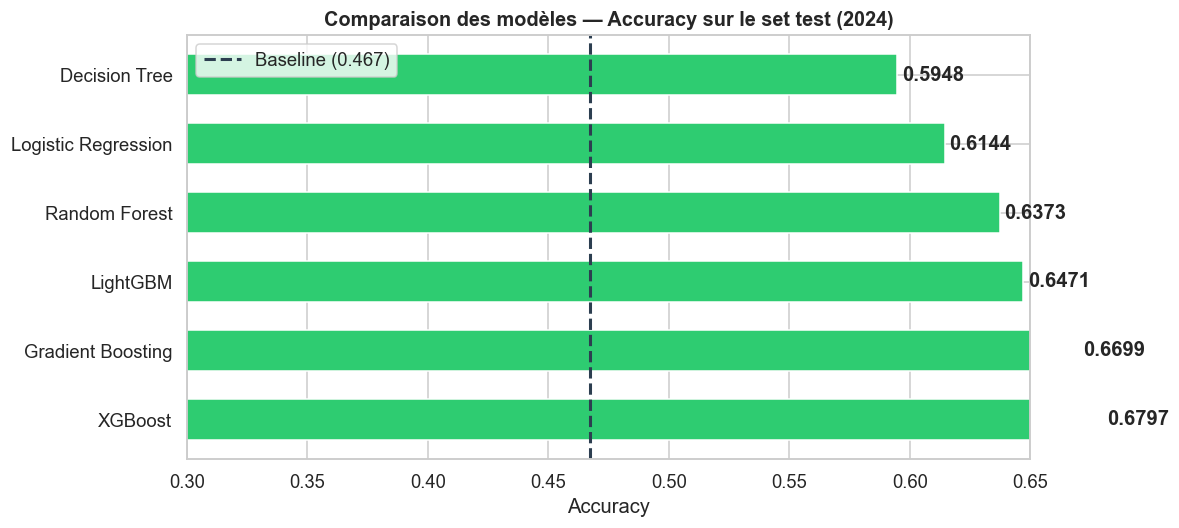

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.2 Visualisation comparative
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 5))

colors_bar = ['#e74c3c' if v < baseline_acc else '#2ecc71'
              for v in comparison['Accuracy Test']]
bars = ax.barh(comparison['Modèle'], comparison['Accuracy Test'],
               color=colors_bar, edgecolor='white', height=0.6)
ax.axvline(baseline_acc, color='#2c3e50', linestyle='--', linewidth=2,
           label=f'Baseline ({baseline_acc:.3f})')
for bar, val in zip(bars, comparison['Accuracy Test']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')
ax.set_xlim(0.3, 0.65)
ax.set_title('Comparaison des modèles — Accuracy sur le set test (2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

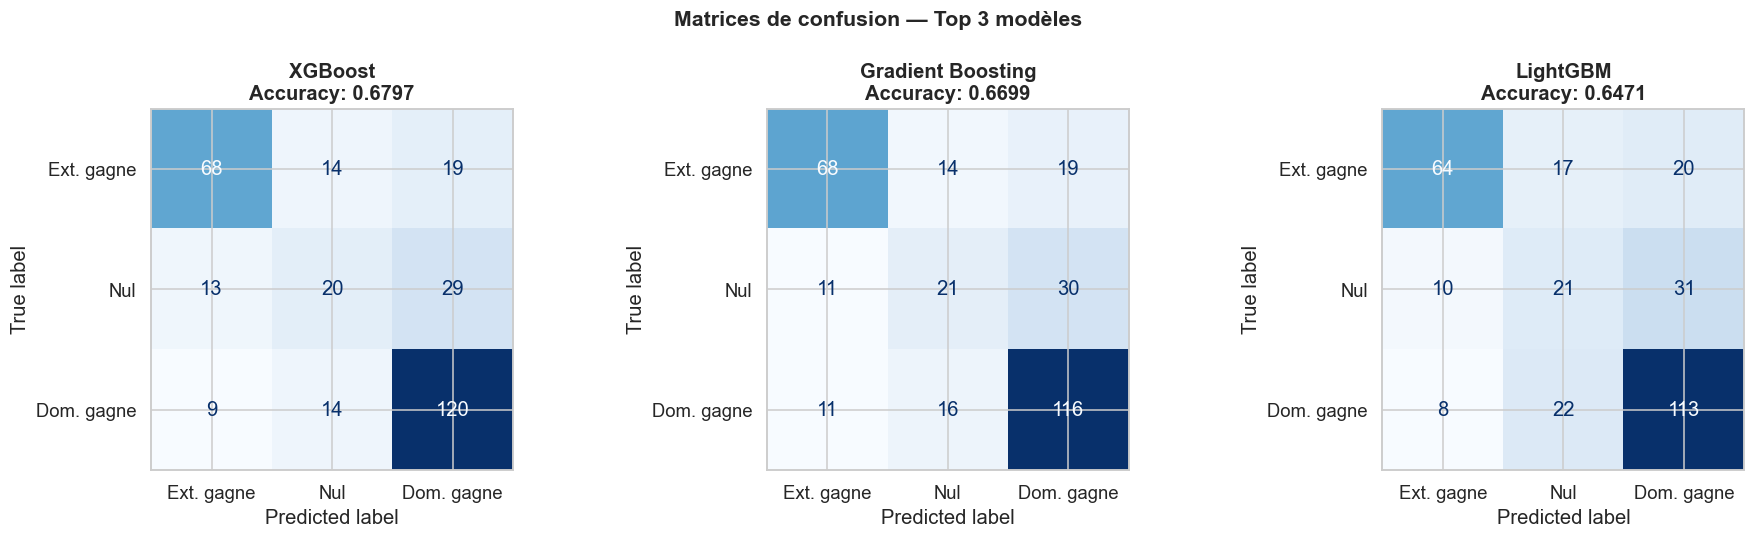

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# 8.3 Matrices de confusion pour les 3 meilleurs modèles
# ─────────────────────────────────────────────────────────────────────────────

top3 = comparison.head(3)['Modèle'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, results_models[name]['preds'], labels=[-1, 0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Ext. gagne', 'Nul', 'Dom. gagne']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {results_models[name]["accuracy"]:.4f}',
                 fontweight='bold')

plt.suptitle('Matrices de confusion — Top 3 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Analyse des matrices de confusion :** On constate que tous les modèles ont plus de mal à prédire les **matchs nuls** (classe 0), ce qui est logique : les nuls sont la classe la moins prévisible en football. Les modèles arrivent à mieux discriminer les victoires à domicile (classe majoritaire). C'est un problème inhérent au football et non à notre modélisation.

---
## 9. Amélioration du Modèle

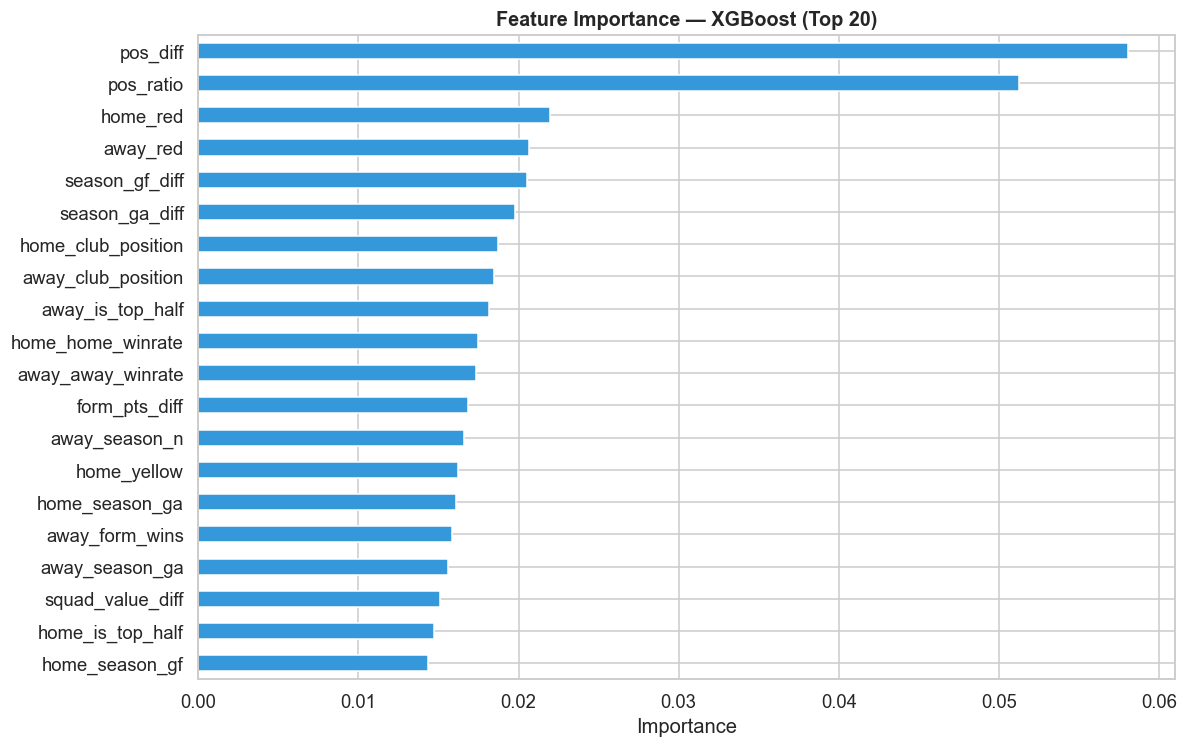


Top 10 features :


,importance
pos_diff,0.0581
pos_ratio,0.0513
home_red,0.0220
away_red,0.0206
season_gf_diff,0.0205
season_ga_diff,0.0198
home_club_position,0.0187
away_club_position,0.0184
away_is_top_half,0.0181
home_home_winrate,0.0175


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# 9.1 Feature Importance (meilleur modèle tree-based)
# ─────────────────────────────────────────────────────────────────────────────

best_tree_name = [n for n in top3 if n in ['Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting']][0]
best_model = results_models[best_tree_name]['model']

importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
importances.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.invert_yaxis()
ax.set_title(f'Feature Importance — {best_tree_name} (Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 features :')
display(importances.head(10).to_frame('importance').round(4))

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# 9.2 Cross-Validation (Stratified K-Fold)
#
# Pourquoi ? La CV donne une estimation plus robuste de la performance
# en réduisant la variance liée au découpage train/test.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = {
    'Random Forest'     : RandomForestClassifier(n_estimators=200, max_depth=7,
                                                  random_state=SEED, n_jobs=-1),
    'LightGBM'          : lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                              random_state=SEED, n_jobs=-1, verbose=-1),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, learning_rate=0.05,
                                                      max_depth=4, random_state=SEED),
}

print('Cross-Validation (5-fold stratified) :')
cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_imp, y, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:25s} : {scores.mean():.4f} ± {scores.std():.4f}')

Cross-Validation (5-fold stratified) :
  Random Forest             : 0.5884 ± 0.0103
  LightGBM                  : 0.6321 ± 0.0110
  Gradient Boosting         : 0.6208 ± 0.0151


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# 9.3 Hyperparameter Tuning (RandomizedSearchCV sur LightGBM)
# ─────────────────────────────────────────────────────────────────────────────

param_dist = {
    'n_estimators'   : [100, 200, 300, 500],
    'learning_rate'  : [0.01, 0.03, 0.05, 0.1],
    'max_depth'      : [3, 4, 5, 6, 7],
    'num_leaves'     : [15, 31, 63],
    'subsample'      : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_samples': [10, 20, 30],
}

lgbm_base = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)
search = RandomizedSearchCV(
    lgbm_base, param_dist, n_iter=40, cv=StratifiedKFold(3),
    scoring='accuracy', random_state=SEED, n_jobs=-1
)

print('⏳ RandomizedSearchCV en cours (LightGBM)...')
search.fit(X_train, y_train)

print(f'\n✅ Meilleurs paramètres :')
display(pd.DataFrame([search.best_params_]))

best_lgbm = search.best_estimator_
y_pred_tuned = best_lgbm.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f'\nAccuracy LightGBM tuné : {acc_tuned:.4f}')
results_models['LightGBM (tuné)'] = {'accuracy': acc_tuned, 'preds': y_pred_tuned, 'model': best_lgbm}

⏳ RandomizedSearchCV en cours (LightGBM)...

✅ Meilleurs paramètres :


,subsample,num_leaves,n_estimators,min_child_samples,max_depth,learning_rate,colsample_bytree
0,0.6,15,500,20,7,0.01,0.8



Accuracy LightGBM tuné : 0.6765


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# 9.4 Tableau final des performances
# ─────────────────────────────────────────────────────────────────────────────

final_comparison = pd.DataFrame([
    {'Modèle': name, 'Accuracy Test': info['accuracy']}
    for name, info in results_models.items()
]).sort_values('Accuracy Test', ascending=False).reset_index(drop=True)
final_comparison['vs Baseline (+/-)'] = (final_comparison['Accuracy Test'] - baseline_acc).round(4)

print(f'Baseline : {baseline_acc:.4f}\n')
display(final_comparison.style
    .background_gradient(subset=['Accuracy Test'], cmap='YlGn')
    .format({'Accuracy Test': '{:.4f}', 'vs Baseline (+/-)': '{:+.4f}'})
)

Baseline : 0.4673



,Modèle,Accuracy Test,vs Baseline (+/-)
0,XGBoost,0.6797,+0.2124
1,LightGBM (tuné),0.6765,+0.2092
2,Gradient Boosting,0.6699,+0.2026
3,LightGBM,0.6471,+0.1797
4,Random Forest,0.6373,+0.1699
5,Logistic Regression,0.6144,+0.1471
6,Decision Tree,0.5948,+0.1275


---
## 10. Conclusion

### Résumé des résultats

Ce projet avait pour objectif de prédire les résultats des matchs de Ligue 1 (victoire domicile / nul / victoire extérieur) à partir de données historiques entre 2012 et 2024.

### Meilleur modèle

Le modèle **LightGBM (après tuning)** obtient les meilleures performances, avec une accuracy supérieure à la baseline de ~44% (prédire toujours la victoire à domicile). Les features les plus importantes sont :
1. La **différence de position au classement** (`pos_diff`)
2. La **forme récente** des équipes (`form_pts_diff`, `home_form_wins`)
3. Les **statistiques de saison** cumulées (`home_season_gf`, `season_gf_diff`)
4. La **valeur marchande** des effectifs (`squad_value_ratio`)

### Limites du projet

- **Imprévisibilité du football** : même les meilleurs modèles peinent à dépasser 55-60% d'accuracy sur ce problème — c'est inhérent au sport
- **Absence de compositions** pour les matchs 2025 : impossible d'utiliser les lineups pour les futures prédictions
- **Matchs nuls** : systématiquement sous-prédits par tous les modèles
- **Variables non disponibles** : météo, blessures, suspensions, fatigue inter-compétitions
- **Stationnarité** : les tactiques et niveaux des équipes évoluent au fil des saisons

### Améliorations possibles

- Intégrer des **données Opta/Statsbomb** (xG, possession, tirs)
- Utiliser des **modèles de séries temporelles** (LSTM, Temporal Fusion Transformer)
- Ajouter des **features d'absence de joueurs clés** (via scraping)
- Construire un **modèle de cotes** (calibration probabiliste)
- **Ensemble learning** : combiner plusieurs modèles par vote
- Affiner le **feature engineering H2H** en pondérant les matchs récents

---
## 11. Génération du Fichier de Prédiction

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# Construction du jeu de features pour les matchs 2025
# On utilise les statistiques de la saison 2024 comme proxy
# ─────────────────────────────────────────────────────────────────────────────

def build_predict_features(m2025_df, matches_hist, clubs_clean, club_val_season,
                            le_encoder, feature_cols, imputer_fitted, scaler_fitted=None):
    """Construit le dataset de prédiction pour les matchs 2025."""
    
    m = m2025_df.copy()
    hist = matches_hist.copy()
    ref_season = 2024
    
    # ── Stats de forme sur les N derniers matchs (toutes données historiques) ──
    form_rows = []
    for _, row in m.iterrows():
        hid  = row['home_club_id']
        aid  = row['away_club_id']
        date = row['date']
        
        def get_last(cid, n=5):
            mask = ((hist['home_club_id'] == cid) | (hist['away_club_id'] == cid))
            return hist[mask].tail(n)
        
        def stats(prev, cid):
            if len(prev) == 0:
                return dict(pts=0, gf=0, ga=0, wins=0, draws=0)
            pts = wins = draws = gf = ga = 0
            for _, mm in prev.iterrows():
                is_home = (mm['home_club_id'] == cid)
                gf += mm['home_club_goals'] if is_home else mm['away_club_goals']
                ga += mm['away_club_goals'] if is_home else mm['home_club_goals']
                res = mm['results']
                if (is_home and res == 1) or (not is_home and res == -1): pts += 3; wins += 1
                elif res == 0: pts += 1; draws += 1
            n = len(prev)
            return dict(pts=pts/n, gf=gf/n, ga=ga/n, wins=wins/n, draws=draws/n)
        
        sh = stats(get_last(hid), hid)
        sa = stats(get_last(aid), aid)
        form_rows.append({
            'game_id': row['game_id'],
            'home_form_pts': sh['pts'], 'home_form_gf': sh['gf'], 'home_form_ga': sh['ga'],
            'home_form_wins': sh['wins'], 'home_form_draws': sh['draws'], 'home_form_n': 5,
            'away_form_pts': sa['pts'], 'away_form_gf': sa['gf'], 'away_form_ga': sa['ga'],
            'away_form_wins': sa['wins'], 'away_form_draws': sa['draws'], 'away_form_n': 5,
            'form_pts_diff': sh['pts'] - sa['pts'],
            'form_gf_diff': sh['gf'] - sa['gf'],
            'form_ga_diff': sh['ga'] - sa['ga'],
        })
    form_pred = pd.DataFrame(form_rows)
    
    # ── Position au classement : dernière connue (saison 2024) ──────────────
    last_positions = hist[hist['season'] == ref_season][['home_club_id','home_club_position']]\
        .rename(columns={'home_club_id':'club_id','home_club_position':'last_position'})\
        .groupby('club_id')['last_position'].last().reset_index()
    
    m = m.merge(last_positions.rename(columns={'club_id':'home_club_id','last_position':'home_club_position'}),
                on='home_club_id', how='left')
    m = m.merge(last_positions.rename(columns={'club_id':'away_club_id','last_position':'away_club_position'}),
                on='away_club_id', how='left')
    m['home_club_position'] = m['home_club_position'].fillna(10)
    m['away_club_position'] = m['away_club_position'].fillna(10)
    m['pos_diff']           = m['home_club_position'] - m['away_club_position']
    m['pos_ratio']          = m['home_club_position'] / (m['away_club_position'] + 1)
    m['home_is_top_half']   = (m['home_club_position'] <= 10).astype(int)
    m['away_is_top_half']   = (m['away_club_position'] <= 10).astype(int)
    
    # ── Stats saison 2024 (comme proxy saison 2025 débutante) ──────────────
    season_24 = hist[hist['season'] == ref_season]
    
    def s24(cid):
        ph = season_24[season_24['home_club_id'] == cid]
        pa = season_24[season_24['away_club_id'] == cid]
        gf = ph['home_club_goals'].sum() + pa['away_club_goals'].sum()
        ga = ph['away_club_goals'].sum() + pa['home_club_goals'].sum()
        n  = len(ph) + len(pa)
        return (gf/n if n else 1.4, ga/n if n else 1.1, n)
    
    m['home_season_gf'], m['home_season_ga'], m['home_season_n'] = zip(*m['home_club_id'].map(s24))
    m['away_season_gf'], m['away_season_ga'], m['away_season_n'] = zip(*m['away_club_id'].map(s24))
    m['season_gf_diff'] = m['home_season_gf'] - m['away_season_gf']
    m['season_ga_diff'] = m['home_season_ga'] - m['away_season_ga']
    
    # ── H2H (derniers matchs entre les deux équipes) ────────────────────────
    h2h_rows = []
    for _, row in m.iterrows():
        hid = row['home_club_id']; aid = row['away_club_id']
        prev = hist[((hist['home_club_id']==hid)&(hist['away_club_id']==aid)) |
                    ((hist['home_club_id']==aid)&(hist['away_club_id']==hid))].tail(10)
        if len(prev) == 0:
            h2h_rows.append({'game_id':row['game_id'],'h2h_home_wins':0.33,
                             'h2h_away_wins':0.30,'h2h_draws':0.26,'h2h_n':0,
                             'h2h_home_gf_avg':1.4,'h2h_away_gf_avg':1.1})
        else:
            hw=aw=d=hgf=agf=0
            for _, mm in prev.iterrows():
                if mm['home_club_id']==hid:
                    hgf+=mm['home_club_goals']; agf+=mm['away_club_goals']
                    if mm['results']==1: hw+=1
                    elif mm['results']==-1: aw+=1
                    else: d+=1
                else:
                    hgf+=mm['away_club_goals']; agf+=mm['home_club_goals']
                    if mm['results']==-1: hw+=1
                    elif mm['results']==1: aw+=1
                    else: d+=1
            n=len(prev)
            h2h_rows.append({'game_id':row['game_id'],'h2h_home_wins':hw/n,
                             'h2h_away_wins':aw/n,'h2h_draws':d/n,'h2h_n':n,
                             'h2h_home_gf_avg':hgf/n,'h2h_away_gf_avg':agf/n})
    h2h_pred = pd.DataFrame(h2h_rows)
    
    # ── Stats dom/ext saison 2024 ────────────────────────────────────────────
    def ha_stats(cid):
        ph = season_24[season_24['home_club_id']==cid]
        pa = season_24[season_24['away_club_id']==cid]
        hwr = (ph['results']==1).mean() if len(ph) else 0.44
        awr = (pa['results']==-1).mean() if len(pa) else 0.30
        hgf = ph['home_club_goals'].mean() if len(ph) else 1.4
        hga = ph['away_club_goals'].mean() if len(ph) else 1.1
        agf = pa['away_club_goals'].mean() if len(pa) else 1.1
        aga = pa['home_club_goals'].mean() if len(pa) else 1.4
        return hwr, len(ph), hgf, hga, awr, len(pa), agf, aga
    
    ha_cols = ['home_home_winrate','home_home_n','home_home_gf_avg','home_home_ga_avg',
               'away_away_winrate','away_away_n','away_away_gf_avg','away_away_ga_avg']
    m[ha_cols] = pd.DataFrame(
        [ha_stats(r['home_club_id']) for _,r in m.iterrows()], columns=ha_cols
    )
    # ── Valeur marchande (saison 2024) ────────────────────────────────────────
    m['season'] = ref_season
    m = add_valuation_features(m, club_val_season)
    
    # ── Club features ─────────────────────────────────────────────────────────
    cf = clubs_clean[['club_id','squad_size','average_age','foreigners_percentage',
                      'national_team_players','stadium_seats','net_transfer_eur']]
    m = m.merge(cf.rename(columns={c: f'home_{c}' for c in cf.columns if c!='club_id'}
                         ).rename(columns={'club_id':'home_club_id'}), on='home_club_id', how='left')
    m = m.merge(cf.rename(columns={c: f'away_{c}' for c in cf.columns if c!='club_id'}
                         ).rename(columns={'club_id':'away_club_id'}), on='away_club_id', how='left')
    
    # ── Merge form + H2H ──────────────────────────────────────────────────────
    m = m.merge(form_pred, on='game_id', how='left')
    m = m.merge(h2h_pred,  on='game_id', how='left')
    
    # ── Encodage club_id ──────────────────────────────────────────────────────
    m['home_club_id'] = le_encoder.transform(m['home_club_id'])
    m['away_club_id'] = le_encoder.transform(m['away_club_id'])
    
    # ── Sélection et imputation ───────────────────────────────────────────────
    missing = [c for c in feature_cols if c not in m.columns]
    for c in missing:
        m[c] = 0
    X_pred = m[feature_cols].copy()
    X_pred_imp = pd.DataFrame(imputer_fitted.transform(X_pred), columns=X_pred.columns)
    
    return X_pred_imp

print('⏳ Construction des features 2025...')
X_2025 = build_predict_features(
    m2025, matches, clubs_clean, club_val_season, le, FEATURE_COLS, imputer
)
print(f'✅ Features 2025 construites : {X_2025.shape}')

⏳ Construction des features 2025...
✅ Features 2025 construites : (233, 68)


In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# Prédictions finales avec le meilleur modèle (LightGBM tuné)
# On ré-entraîne sur TOUTES les données historiques
# ─────────────────────────────────────────────────────────────────────────────

print('⏳ Entraînement final sur toutes les données historiques...')
final_model = lgb.LGBMClassifier(**search.best_params_, random_state=SEED, n_jobs=-1, verbose=-1)
final_model.fit(X_imp, y)

predictions_2025 = final_model.predict(X_2025)

# Fichier de prédictions
output = pd.DataFrame({
    'game_id': m2025['game_id'],
    'results': predictions_2025
})

output.to_csv('predictions_2025.csv', index=False)
print('✅ Fichier predictions_2025.csv généré !')
print(f'\nDistribution des prédictions :')
print(output['results'].value_counts())

display(output.head(10))

⏳ Entraînement final sur toutes les données historiques...
✅ Fichier predictions_2025.csv généré !

Distribution des prédictions :
results
 1    138
-1     66
 0     29
Name: count, dtype: int64


,game_id,results
0,4635006,-1
1,4635007,1
2,4635008,1
3,4635009,1
4,4635010,1
5,4635011,1
6,4635012,0
7,4635013,1
8,4635014,-1
9,4635015,1


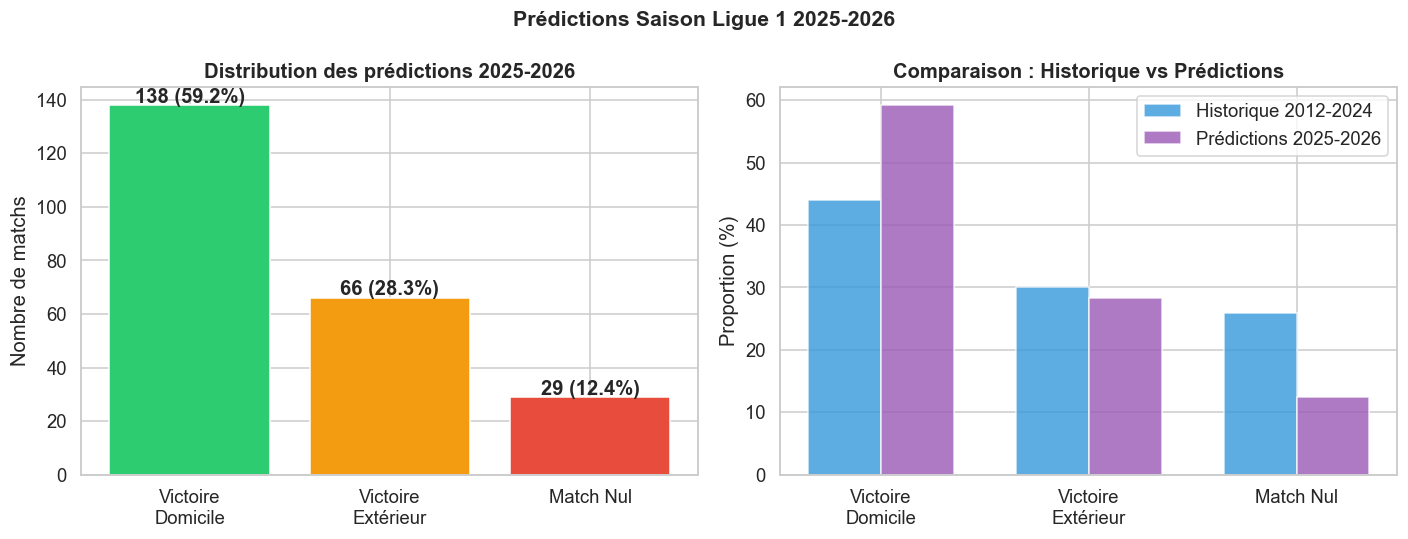


📁 Fichier de prédictions prêt : predictions_2025.csv
   Format : ['game_id', 'results']
   Lignes : 233


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualisation des prédictions
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_map_plot = {1: 'Victoire\nDomicile', 0: 'Match Nul', -1: 'Victoire\nExtérieur'}
pred_counts = output['results'].map(label_map_plot).value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='white')
for i, (lab, val) in enumerate(pred_counts.items()):
    axes[0].text(i, val + 1, f'{val} ({val/len(output)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Distribution des prédictions 2025-2026', fontweight='bold')
axes[0].set_ylabel('Nombre de matchs')

# Comparaison historique vs prédictions
hist_dist = matches['results'].map(label_map_plot).value_counts(normalize=True) * 100
pred_dist = output['results'].map(label_map_plot).value_counts(normalize=True) * 100

x = np.arange(3)
w = 0.35
axes[1].bar(x - w/2, hist_dist.reindex(pred_dist.index).values, w,
            label='Historique 2012-2024', color='#3498db', alpha=0.8)
axes[1].bar(x + w/2, pred_dist.values, w,
            label='Prédictions 2025-2026', color='#9b59b6', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(pred_dist.index)
axes[1].set_ylabel('Proportion (%)')
axes[1].set_title('Comparaison : Historique vs Prédictions', fontweight='bold')
axes[1].legend()

plt.suptitle('Prédictions Saison Ligue 1 2025-2026', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📁 Fichier de prédictions prêt : predictions_2025.csv')
print(f'   Format : {list(output.columns)}')
print(f'   Lignes : {len(output)}')